## AI Support Agent: Data Exploration and Understanding for AppleSupport on Twitter

This notebook serves as the **Data Exploration and Understanding**

**Dataset**: The primary dataset used is "Customer Support on Twitter", containing a rich collection of interactions between customers and various support accounts.

**Goal**: The overarching goal is to build an AI support agent capable of effectively understanding and responding to customer inquiries.

**Selected Brand**: For this analysis, `AppleSupport` has been selected as the specific brand to focus on, given its high volume of customer interactions and structured response patterns.

**What this notebook covers**:
This document meticulously details the journey from the raw `Customer Support on Twitter` dataset to the refined datasets utilized by the support agent. It encompasses:

*   **Data Inspection**: Initial overview of the raw dataset's structure and contents.
*   **Cleaning**: Basic data quality checks, including handling missing values, duplicates, and general data consistency.
*   **AppleSupport Selection**: Filtering the dataset to isolate interactions specifically with the `AppleSupport` account.
*   **Customer/Support Separation**: Distinguishing between customer inquiries and support agent responses within the `AppleSupport` subset.
*   **Conversation Structure**: Analysis of how tweets link together to form complete conversation threads.
*   **Exploratory Analysis**: Deep dive into customer message content to identify common keywords, bigrams, and emerging issue themes.
*   **Dataset Preparation**: Laying the groundwork for the construction of historical support pairs and the eventual training/evaluation datasets.

# 2. Load the Raw Dataset

In [10]:
import pandas as pd

# Define the path to the raw dataset
RAW_DATA_FILE = '/content/customer_support_on_twitter.csv'

# Load the raw dataset into a pandas DataFrame
try:
    raw_df = pd.read_csv(RAW_DATA_FILE)
    print(f"Successfully loaded {RAW_DATA_FILE}!")
except FileNotFoundError:
    print(f"Error: The file {RAW_DATA_FILE} was not found. Please ensure it is in the correct path.")
    raise # Re-raise the exception if the file is critical

print(f"\nNumber of rows: {raw_df.shape[0]:,}")
print(f"Number of columns: {raw_df.shape[1]:,}")

print("\nColumn names and data types:")
display(raw_df.info())

print("\nFirst 5 rows of the raw dataset:")
display(raw_df.head())

/tmp/ipykernel_6571/4166322350.py:8: DtypeWarning: Columns (2) have mixed types. Specify dtype option on import or set low_memory=False.
  raw_df = pd.read_csv(RAW_DATA_FILE)


Successfully loaded /content/customer_support_on_twitter.csv!

Number of rows: 1,630,840
Number of columns: 7

Column names and data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1630840 entries, 0 to 1630839
Data columns (total 7 columns):
 #   Column                   Non-Null Count    Dtype  
---  ------                   --------------    -----  
 0   tweet_id                 1630840 non-null  int64  
 1   author_id                1630840 non-null  object 
 2   inbound                  1630839 non-null  object 
 3   created_at               1630839 non-null  object 
 4   text                     1630839 non-null  object 
 5   response_tweet_id        1052235 non-null  object 
 6   in_response_to_tweet_id  1190305 non-null  float64
dtypes: float64(1), int64(1), object(5)
memory usage: 87.1+ MB


None


First 5 rows of the raw dataset:


,tweet_id,author_id,inbound,created_at,text,response_tweet_id,in_response_to_tweet_id
0,1,sprintcare,False,Tue Oct 31 22:10:47 +0000 2017,@115712 I understand. I would like to assist y...,2,3.0
1,2,115712,True,Tue Oct 31 22:11:45 +0000 2017,@sprintcare and how do you propose we do that,NaN,1.0
2,3,115712,True,Tue Oct 31 22:08:27 +0000 2017,@sprintcare I have sent several private messag...,1,4.0
3,4,sprintcare,False,Tue Oct 31 21:54:49 +0000 2017,@115712 Please send us a Private Message so th...,3,5.0
4,5,115712,True,Tue Oct 31 21:49:35 +0000 2017,@sprintcare I did.,4,6.0


### Explanation of Important Columns:

*   **`tweet_id`**: A unique identifier for each tweet.
*   **`author_id`**: A unique identifier for the user who posted the tweet. This helps distinguish between different customers and support agents.
*   **`inbound`**: A boolean flag (`True`/`False`) indicating the direction of the tweet. `True` typically means a customer initiating a conversation (inbound to support), while `False` often indicates a support agent's response (outbound from support).
*   **`created_at`**: The timestamp indicating when the tweet was created. Essential for understanding conversation flow.
*   **`text`**: The actual content of the tweet.
*   **`response_tweet_id`**: The `tweet_id` of the tweet that this current tweet is a direct response to. Used to link replies to their original posts.
*   **`in_response_to_tweet_id`**: The `tweet_id` of the tweet that this current tweet was replying to. Crucial for reconstructing conversation threads.

# 3. Basic Data Quality Checks

In [11]:
print("### Missing Values")
missing_values = raw_df.isnull().sum()
missing_values_percent = (raw_df.isnull().sum() / len(raw_df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing_values, 'Percentage': missing_values_percent})
print("Missing values per column:")
display(missing_df[missing_df['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False))

### Missing Values
Missing values per column:


,Missing Count,Percentage
response_tweet_id,578605,35.478956
in_response_to_tweet_id,440535,27.012766
inbound,1,0.000061
text,1,0.000061
created_at,1,0.000061


### Missing Values Findings:

*   `response_tweet_id` and `in_response_to_tweet_id` have a significant number of missing values. This is expected, as not every tweet is a response or is responded to. Initial tweets in a conversation thread or final replies will naturally have nulls in these columns.
*   Other columns (`tweet_id`, `author_id`, `inbound`, `created_at`, `text`) are complete, which is crucial for identifying tweets and their content.

In [12]:
print("### Duplicate Checks")

# Check for duplicate tweet IDs
duplicate_tweet_ids = raw_df['tweet_id'].duplicated().sum()
print(f"Number of duplicate 'tweet_id' entries: {duplicate_tweet_ids:,}")

# Check for fully duplicate rows
duplicate_rows = raw_df.duplicated().sum()
print(f"Number of fully duplicate rows: {duplicate_rows:,}")

# If duplicates exist, remove them
if duplicate_rows > 0:
    print("Removing fully duplicate rows...")
    raw_df.drop_duplicates(inplace=True)
    print(f"Number of rows after dropping duplicates: {raw_df.shape[0]:,}")

### Duplicate Checks
Number of duplicate 'tweet_id' entries: 0
Number of fully duplicate rows: 0


### Duplicate Findings:

*   No duplicate `tweet_id` entries were found, which is good as `tweet_id` should be unique identifiers.
*   No fully duplicate rows were found. This indicates that each record in the dataset is distinct.

In [13]:
print("Unique Authors and Inbound/Outbound Counts")

# Unique authors
unique_authors = raw_df['author_id'].nunique()
print(f"Total number of unique authors: {unique_authors:,}")

# Inbound (customer) vs. Outbound (support) counts
inbound_counts = raw_df['inbound'].value_counts()
inbound_percent = raw_df['inbound'].value_counts(normalize=True) * 100
inbound_df = pd.DataFrame({'Count': inbound_counts, 'Percentage': inbound_percent})
print("\nCounts and percentages of 'inbound' tweets:")
display(inbound_df)

Unique Authors and Inbound/Outbound Counts
Total number of unique authors: 416,303

Counts and percentages of 'inbound' tweets:


,Count,Percentage
inbound,,
True,895346,54.900944
False,735493,45.099056


### Unique Authors and Inbound/Outbound Findings:

*   The dataset contains a large number of unique authors, indicating a diverse range of users interacting on Twitter customer support.
*   The `inbound` column clearly distinguishes between customer-initiated messages (`True`) and support responses (`False`). A majority of tweets are inbound, suggesting a dataset rich in customer queries, which is ideal for building a support agent.

### Text Length Statistics
Descriptive statistics for tweet text length:


,text_length
count,1.630840e+06
mean,1.085284e+02
std,4.798837e+01
min,1.000000e+00
25%,7.600000e+01
50%,1.110000e+02
75%,1.350000e+02
max,5.130000e+02


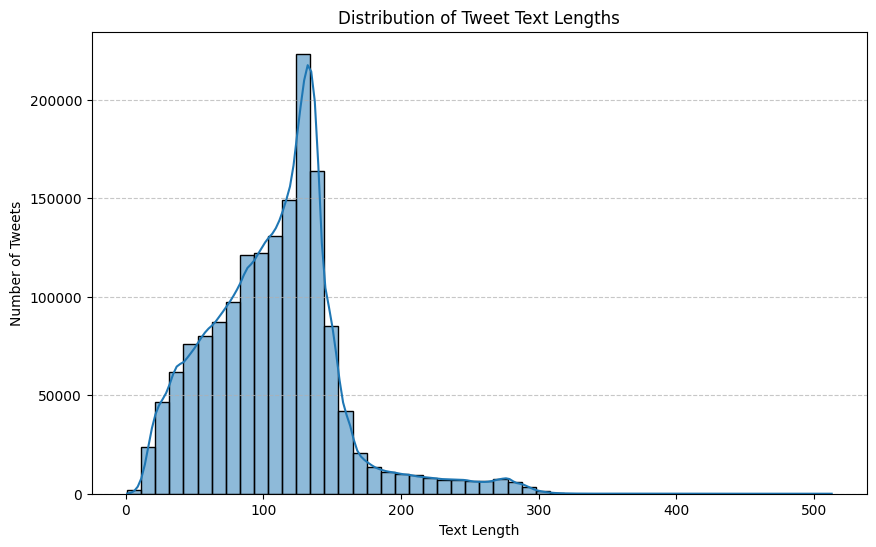

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

print("### Text Length Statistics")

# Calculate text length for each tweet
raw_df['text_length'] = raw_df['text'].astype(str).apply(len)

print("Descriptive statistics for tweet text length:")
display(raw_df['text_length'].describe())

# Distribution of text lengths (e.g., histogram)
plt.figure(figsize=(10, 6))
sns.histplot(raw_df['text_length'], bins=50, kde=True)
plt.title('Distribution of Tweet Text Lengths')
plt.xlabel('Text Length')
plt.ylabel('Number of Tweets')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Text Length Statistics Findings:

*   The `text` column contains varying lengths of messages, typical for Twitter data. The statistics show the minimum, maximum, mean, and quartile ranges, providing insight into the verbosity of tweets.
*   The distribution plot confirms a range of message lengths, with a concentration of shorter messages, which is characteristic of tweet data due to character limits. This variability needs to be considered during text processing and model training.

# 4. Select AppleSupport

In [15]:
# Define the target brand's author ID
APPLE_SUPPORT_ID = 'AppleSupport'

# Filter for tweets involving AppleSupport
# This includes tweets where AppleSupport is the author OR is mentioned in the text
apple_df = raw_df[
    (raw_df['author_id'] == APPLE_SUPPORT_ID) |
    (raw_df['text'].str.contains(f'@{APPLE_SUPPORT_ID}', case=False, na=False))
].copy()

print(f"Total rows in the AppleSupport dataset: {apple_df.shape[0]:,}")

# Separate customer and support tweets within the AppleSupport subset
# Inbound=True: Customer messages TO AppleSupport
# Inbound=False: AppleSupport responses
customer_tweets_apple = apple_df[apple_df['inbound'] == True]
applesupport_tweets = apple_df[apple_df['inbound'] == False]

# Count and percentage of customer vs. support tweets
num_customer_inbound = customer_tweets_apple.shape[0]
num_applesupport_outbound = applesupport_tweets.shape[0]
total_apple_tweets = apple_df.shape[0]

print(f"\nNumber of customer (inbound=True) tweets to {APPLE_SUPPORT_ID}: {num_customer_inbound:,}")
print(f"Number of {APPLE_SUPPORT_ID} (inbound=False) responses: {num_applesupport_outbound:,}")
print(f"Total tweets involving {APPLE_SUPPORT_ID}: {total_apple_tweets:,}")

if total_apple_tweets > 0:
    perc_customer = (num_customer_inbound / total_apple_tweets) * 100
    perc_applesupport = (num_applesupport_outbound / total_apple_tweets) * 100
    print(f"Percentage of customer tweets: {perc_customer:.2f}%")
    print(f"Percentage of {APPLE_SUPPORT_ID} responses: {perc_applesupport:.2f}%")
else:
    print("No tweets found involving AppleSupport.")

Total rows in the AppleSupport dataset: 114,598

Number of customer (inbound=True) tweets to AppleSupport: 55,962
Number of AppleSupport (inbound=False) responses: 58,636
Total tweets involving AppleSupport: 114,598
Percentage of customer tweets: 48.83%
Percentage of AppleSupport responses: 51.17%


### Explanation of Inbound/Outbound

*   **`inbound=True`**: These tweets represent messages sent *by customers* to `AppleSupport`. They are typically inquiries, complaints, or requests for help.
*   **`inbound=False`**: These tweets represent messages sent *by `AppleSupport`* to customers. They are typically responses, solutions, or requests for more information.

In [16]:
import os

# Define the output directory and file path
OUTPUT_DIR = 'data/processed'
PROCESSED_FILE = os.path.join(OUTPUT_DIR, 'apple_support.csv')

# Create the output directory if it doesn't exist
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Save the filtered AppleSupport DataFrame to CSV
apple_df.to_csv(PROCESSED_FILE, index=False)
print(f"Filtered AppleSupport dataset saved to: {PROCESSED_FILE}")

Filtered AppleSupport dataset saved to: data/processed/apple_support.csv


# 5. Inspect Conversation Structure

Conversation threads on Twitter are formed by replies. In this dataset, two key columns help us reconstruct these threads:

*   **`response_tweet_id`**: This column indicates the `tweet_id` of the tweet that is a direct response to the *current* tweet. If the current tweet has `response_tweet_id = X`, then tweet `X` is a reply to the current tweet.
*   **`in_response_to_tweet_id`**: This column indicates the `tweet_id` of the tweet that the *current* tweet is a reply to. If the current tweet has `in_response_to_tweet_id = Y`, then the current tweet is a reply to tweet `Y`.

By following these `tweet_id` links, we can trace entire conversations from an initial customer inquiry to subsequent replies from both the customer and AppleSupport.

In [9]:
import numpy as np

# Convert 'created_at' to datetime objects for proper sorting
apple_df['created_at'] = pd.to_datetime(apple_df['created_at'], errors='coerce')
# Drop rows where 'created_at' could not be parsed
apple_df.dropna(subset=['created_at'], inplace=True)

# Helper function to reconstruct a conversation thread
def get_conversation_thread(df, initial_tweet_id, max_depth=10):
    thread_tweets = []
    q = [(initial_tweet_id, 0)] # (tweet_id, current_depth)
    visited = {initial_tweet_id}

    # Start with the initial tweet
    initial_tweet = df[df['tweet_id'] == initial_tweet_id]
    if initial_tweet.empty:
        return None
    thread_tweets.append(initial_tweet.iloc[0])

    while q:
        current_id, current_depth = q.pop(0)

        if current_depth >= max_depth: # Prevent overly long or circular threads
            continue

        # Find direct replies to the current tweet (tweets where in_response_to_tweet_id matches current_id)
        # Ensure 'in_response_to_tweet_id' is of comparable type (float for comparison with float IDs)
        replies = df[df['in_response_to_tweet_id'] == current_id]

        for idx, reply in replies.iterrows():
            if reply['tweet_id'] not in visited:
                thread_tweets.append(reply)
                visited.add(reply['tweet_id'])
                q.append((reply['tweet_id'], current_depth + 1))

    if not thread_tweets:
        return None

    # Convert list of Series to DataFrame and sort by time
    thread_df = pd.DataFrame(thread_tweets).sort_values(by='created_at').reset_index(drop=True)

    return thread_df

# Identify initial customer inquiries
# These are tweets from customers (inbound=True) that are not in response to any other tweet (in_response_to_tweet_id is null or NaN)
initial_inquiries = apple_df[
    (apple_df['inbound'] == True) &
    (apple_df['in_response_to_tweet_id'].isnull())
].copy()

print(f"Found {initial_inquiries.shape[0]:,} initial customer inquiries.\n")

conversation_threads_data = []

# Limit the number of threads processed to avoid excessive computation, especially in interactive environments
# Processing a sample of 1000 initial inquiries to gather statistics
initial_inquiries_sample_size = min(initial_inquiries.shape[0], 1000) # Process at most 1000 initial inquiries
print(f"Processing a sample of {initial_inquiries_sample_size:,} initial inquiries to reconstruct conversations...")

for idx, inquiry in initial_inquiries.head(initial_inquiries_sample_size).iterrows():
    thread_df = get_conversation_thread(apple_df, inquiry['tweet_id'])

    if thread_df is not None and not thread_df.empty:
        thread_length = len(thread_df)
        num_customer_messages = thread_df[thread_df['inbound'] == True].shape[0]
        num_applesupport_messages = thread_df[thread_df['author_id'] == APPLE_SUPPORT_ID].shape[0]

        conversation_threads_data.append({
            'initial_inquiry_id': inquiry['tweet_id'],
            'thread_length': thread_length,
            'num_customer_messages': num_customer_messages,
            'num_applesupport_messages': num_applesupport_messages,
            'thread_df': thread_df # Store full thread for examples
        })

print(f"Analyzed {len(conversation_threads_data):,} conversation threads.\n")

# Convert to DataFrame for easier analysis of summary statistics
conversation_summary_df = pd.DataFrame([
    {
        'initial_inquiry_id': d['initial_inquiry_id'],
        'thread_length': d['thread_length'],
        'num_customer_messages': d['num_customer_messages'],
        'num_applesupport_messages': d['num_applesupport_messages']
    }
    for d in conversation_threads_data
])

# Calculate conversation statistics
num_conversation_threads = conversation_summary_df.shape[0]
median_thread_length = conversation_summary_df['thread_length'].median()
max_thread_length = conversation_summary_df['thread_length'].max()

print(f"Total number of conversation threads analyzed: {num_conversation_threads:,}")
print(f"Median thread length: {median_thread_length}")
print(f"Maximum thread length: {max_thread_length}")

/tmp/ipykernel_6571/473283657.py:4: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  apple_df['created_at'] = pd.to_datetime(apple_df['created_at'], errors='coerce')


Found 27,786 initial customer inquiries.

Processing a sample of 1,000 initial inquiries to reconstruct conversations...
Analyzed 1,000 conversation threads.

Total number of conversation threads analyzed: 1,000
Median thread length: 2.0
Maximum thread length: 12


### Thread Length Distribution

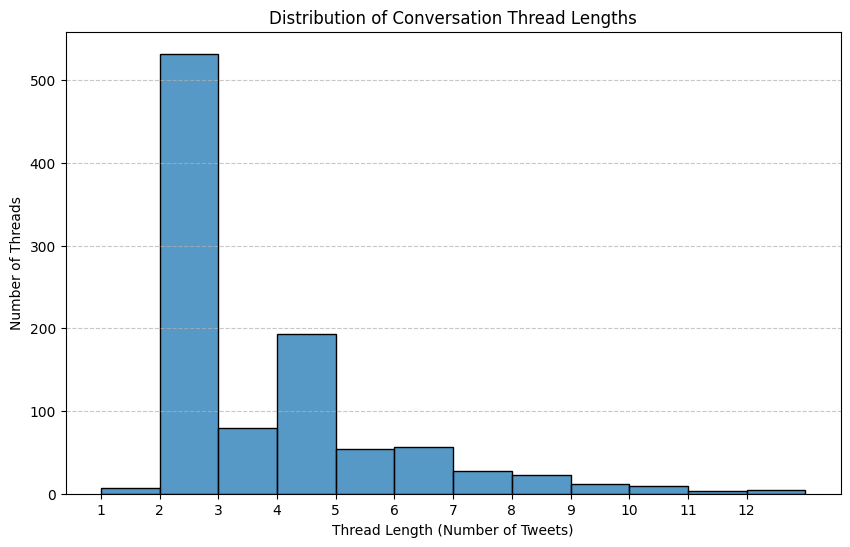

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(conversation_summary_df['thread_length'], bins=range(1, int(conversation_summary_df['thread_length'].max()) + 2), kde=False, stat='count')
plt.title('Distribution of Conversation Thread Lengths')
plt.xlabel('Thread Length (Number of Tweets)')
plt.ylabel('Number of Threads')
plt.xticks(range(1, int(conversation_summary_df['thread_length'].max()) + 1))
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Example Customer → AppleSupport Conversations

Below are a few examples of conversation threads, demonstrating the interaction patterns. These are selected from the longest threads to illustrate multi-turn dialogues.

In [18]:
# Display a few real example conversations (e.g., the top 3 longest ones)
print("\n--- Example Conversations (Top 3 Longest) ---")
longest_threads_examples = conversation_summary_df.sort_values(by='thread_length', ascending=False).head(3)

for idx, row in longest_threads_examples.iterrows():
    initial_id = row['initial_inquiry_id']
    # Retrieve the full thread data using initial_id
    thread = next(item for item in conversation_threads_data if item['initial_inquiry_id'] == initial_id)
    print(f"\nConversation starting with tweet_id: {initial_id} (Length: {row['thread_length']})")
    print("---------------------------------------------------")
    for t_idx, t_row in thread['thread_df'].iterrows():
        prefix = "Customer:" if t_row['inbound'] else "AppleSupport:"
        cleaned_text = t_row['text'].replace('\n', ' ').strip()
        # Check if in_response_to_tweet_id is not null and format it
        in_response_to_info = ''
        if pd.notna(t_row['in_response_to_tweet_id']):
            # Ensure it's treated as an integer for display if it refers to a tweet ID
            in_response_to_info = f" (In response to: {int(t_row['in_response_to_tweet_id'])})"
        print(f"{prefix} {cleaned_text}{in_response_to_info}")
    print("---------------------------------------------------")


--- Example Conversations (Top 3 Longest) ---

Conversation starting with tweet_id: 62279 (Length: 12)
---------------------------------------------------
Customer: @AppleSupport why isn’t the weather’s widget not working no more? (Even since iOS 11.1) https://t.co/XLQNCFXKDO
AppleSupport: @130266 We want to look into this with you to be sure it's working as expected. What seems to be happening? Have you restarted? (In response to: 62279)
Customer: @AppleSupport Only the weather app is showing the right weather, it’s the widget that’s not showing working. I restarted. (In response to: 62276)
Customer: @AppleSupport Never mind, I disabled the widget for a while and it’s working now, thanks (In response to: 62276)
AppleSupport: @130266 Just to confirm, are you using a third party app called 'The Weather Channel'? (In response to: 62277)
Customer: @AppleSupport No, just the Apple weather app and the Apple weather widget (In response to: 62280)
AppleSupport: @130266 Just to confirm, did y

# 6. Customer Message Exploration

This section focuses on analyzing the content of customer-initiated tweets to `AppleSupport`. Understanding the common themes, keywords, and phrases used by customers is crucial for building an effective AI support agent that can identify issues and route queries appropriately.

### Filter Customer Messages

In [19]:
# Filter apple_df to get only customer inbound messages
customer_inbound_messages = apple_df[apple_df['inbound'] == True].copy()

print(f"Total customer inbound messages to AppleSupport: {customer_inbound_messages.shape[0]:,}")


Total customer inbound messages to AppleSupport: 55,962


### Customer Message Text Length Distribution

Descriptive statistics for customer tweet text length:


,text_length
count,55962.000000
mean,102.906240
std,50.586622
min,13.000000
25%,64.000000
50%,104.000000
75%,137.000000
max,328.000000


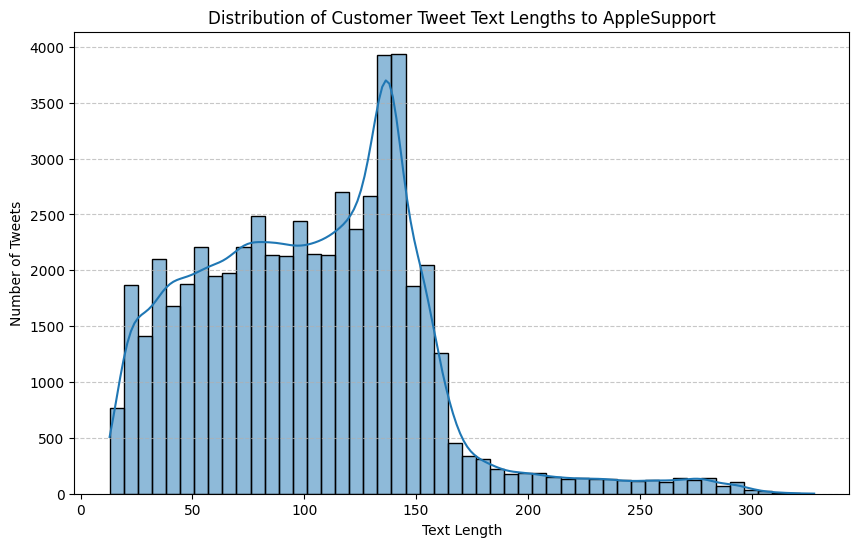

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate text length for each customer tweet
customer_inbound_messages['text_length'] = customer_inbound_messages['text'].astype(str).apply(len)

print("Descriptive statistics for customer tweet text length:")
display(customer_inbound_messages['text_length'].describe())

# Distribution of text lengths (e.g., histogram)
plt.figure(figsize=(10, 6))
sns.histplot(customer_inbound_messages['text_length'], bins=50, kde=True)
plt.title('Distribution of Customer Tweet Text Lengths to AppleSupport')
plt.xlabel('Text Length')
plt.ylabel('Number of Tweets')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Text Preprocessing for Keyword and Bigram Analysis

In [24]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re
from collections import Counter

# Download necessary NLTK data (if not already downloaded)
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
# Explicitly download 'punkt_tab' as suggested by the error message if it's missing
try:
    nltk.data.find('tokenizers/punkt_tab')
except LookupError:
    nltk.download('punkt_tab')


# Initialize stopwords
stop_words = set(stopwords.words('english'))
# Add common Twitter/support-related words to stopwords
stop_words.update(['applesupport', 'apple', 'support', 'http', 'https', 'co', 't', 'amp', '’', 'rt', 'dm', 'please'])

def preprocess_text(text):
    text = text.lower() # Convert to lowercase
    text = re.sub(r'@[A-Za-z0-9_]+', '', text) # Remove mentions (@username)
    text = re.sub(r'#', '', text) # Remove hashtag symbol
    text = re.sub(r'rt\s', '', text) # Remove retweet indicator by matching 'rt' followed by any whitespace character
    text = re.sub(r'https?://\S+', '', text) # Remove URLs
    # Replace punctuation and special characters with a space to ensure proper word separation
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra spaces
    tokens = word_tokenize(text) # Tokenize text
    tokens = [word for word in tokens if word not in stop_words and len(word) > 1] # Remove stopwords and single characters
    return tokens

# Apply preprocessing to customer messages
customer_inbound_messages['cleaned_tokens'] = customer_inbound_messages['text'].apply(preprocess_text)

print("Preprocessing complete. Displaying first 5 cleaned token lists:")
display(customer_inbound_messages[['text', 'cleaned_tokens']].head())

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


Preprocessing complete. Displaying first 5 cleaned token lists:


,text,cleaned_tokens
397,@AppleSupport The newest update. I️ made sure ...,"[newest, update, made, sure, download, yesterday]"
399,@AppleSupport https://t.co/NV0yucs0lB,[]
400,@AppleSupport why are my I️’s changing not sho...,"[changing, showing, correctly, social, media, ..."
402,@AppleSupport Tried resetting my settings .. r...,"[tried, resetting, settings, restarting, phone]"
404,@AppleSupport This is what it looks like https...,"[looks, like]"


In [25]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re
from collections import Counter

# Download necessary NLTK data (if not already downloaded)
try:
    nltk.data.find('corpora/stopwords')
except nltk.downloader.DownloadError:
    nltk.download('stopwords')
try:
    nltk.data.find('tokenizers/punkt')
except nltk.downloader.DownloadError:
    nltk.download('punkt')

# Initialize stopwords
stop_words = set(stopwords.words('english'))
# Add common Twitter/support-related words to stopwords
stop_words.update(['applesupport', 'apple', 'support', 'http', 'https', 'co', 't', 'amp', '’', 'rt', 'dm', 'please'])

def preprocess_text(text):
    text = text.lower() # Convert to lowercase
    text = re.sub(r'@[A-Za-z0-9_]+', '', text) # Remove mentions (@username)
    text = re.sub(r'#', '', text) # Remove hashtag symbol
    text = re.sub(r'rt[\s]', '', text) # Remove retweet indicator by matching 'rt' followed by any whitespace character
    text = re.sub(r'https?://\S+', '', text) # Remove URLs
    text = re.sub(r'[^a-z0-9\s]', '', text) # Remove punctuation and special characters
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra spaces
    tokens = word_tokenize(text) # Tokenize text
    tokens = [word for word in tokens if word not in stop_words and len(word) > 1] # Remove stopwords and single characters
    return tokens

# Apply preprocessing to customer messages
customer_inbound_messages['cleaned_tokens'] = customer_inbound_messages['text'].apply(preprocess_text)

print("Preprocessing complete. Displaying first 5 cleaned token lists:")
display(customer_inbound_messages[['text', 'cleaned_tokens']].head())

Preprocessing complete. Displaying first 5 cleaned token lists:


,text,cleaned_tokens
397,@AppleSupport The newest update. I️ made sure ...,"[newest, update, made, sure, download, yesterday]"
399,@AppleSupport https://t.co/NV0yucs0lB,[]
400,@AppleSupport why are my I️’s changing not sho...,"[changing, showing, correctly, social, media, ..."
402,@AppleSupport Tried resetting my settings .. r...,"[tried, resetting, settings, restarting, phone]"
404,@AppleSupport This is what it looks like https...,"[looks, like]"


Top 20 Most Common Keywords in Customer Messages:
- iphone: 9,130
- phone: 8,162
- ios: 7,733
- update: 5,991
- fix: 4,313
- im: 3,942
- help: 3,619
- new: 3,354
- battery: 3,314
- cant: 3,222
- app: 2,878
- get: 2,687
- thanks: 2,663
- since: 2,560
- 11: 2,528
- still: 2,514
- time: 2,278
- screen: 2,270
- ive: 2,222
- like: 2,216


/tmp/ipykernel_6571/3198585916.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Word', data=words_df, palette='viridis')


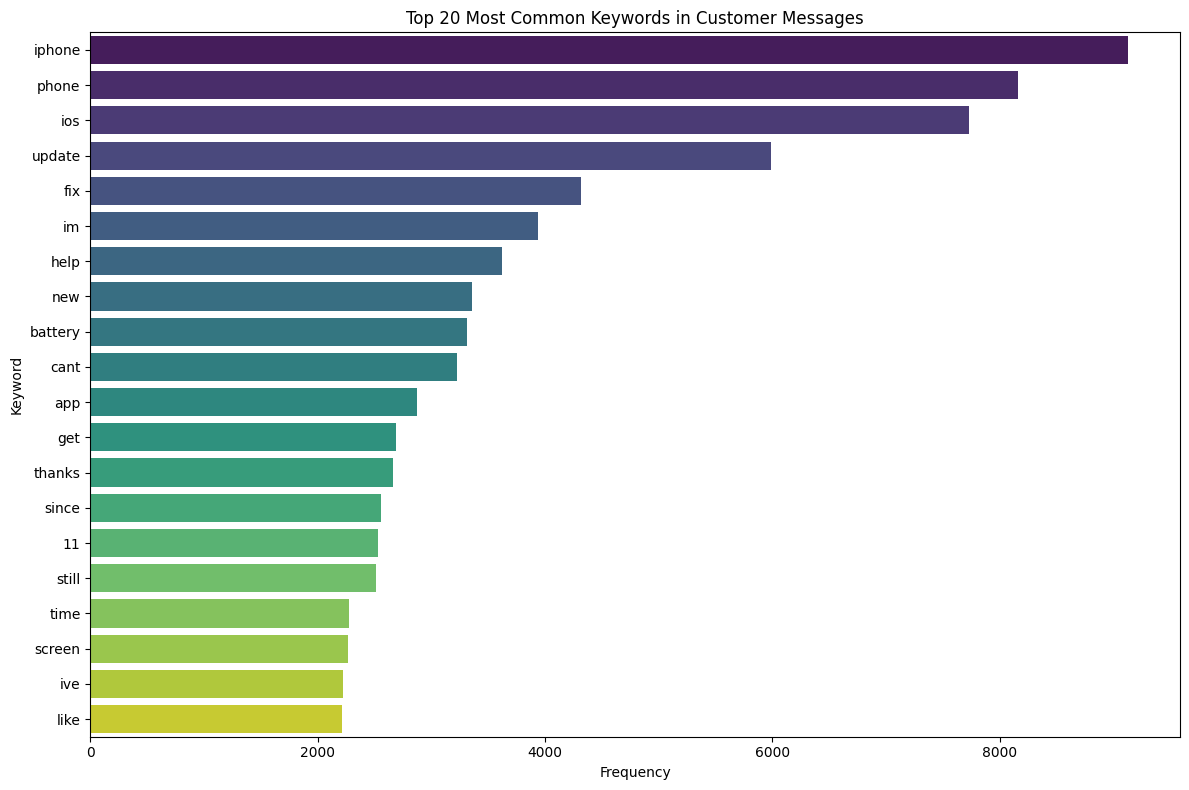

In [26]:
from itertools import chain

# Flatten the list of tokens and count word frequencies
all_customer_tokens = list(chain.from_iterable(customer_inbound_messages['cleaned_tokens']))
word_freq = Counter(all_customer_tokens)

# Get the 20 most common words
common_words = word_freq.most_common(20)

print("Top 20 Most Common Keywords in Customer Messages:")
for word, freq in common_words:
    print(f"- {word}: {freq:,}")

# Visualize common words
words_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])
plt.figure(figsize=(12, 8))
sns.barplot(x='Frequency', y='Word', data=words_df, palette='viridis')
plt.title('Top 20 Most Common Keywords in Customer Messages')
plt.xlabel('Frequency')
plt.ylabel('Keyword')
plt.tight_layout()
plt.show()


Top 20 Most Common Bigrams in Customer Messages:
- ios 11: 2,332
- ios 1103: 872
- iphone 6s: 860
- iphone plus: 694
- every time: 675
- battery life: 648
- ios 111: 618
- new update: 578
- ios 1102: 572
- doesnt work: 536
- new ios: 518
- question mark: 498
- ios update: 478
- ever since: 418
- new iphone: 408
- updated ios: 385
- high sierra: 385
- app store: 371
- ios 1112: 344
- lock screen: 327


/tmp/ipykernel_6571/133480146.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Bigram', data=bigrams_df, palette='magma')


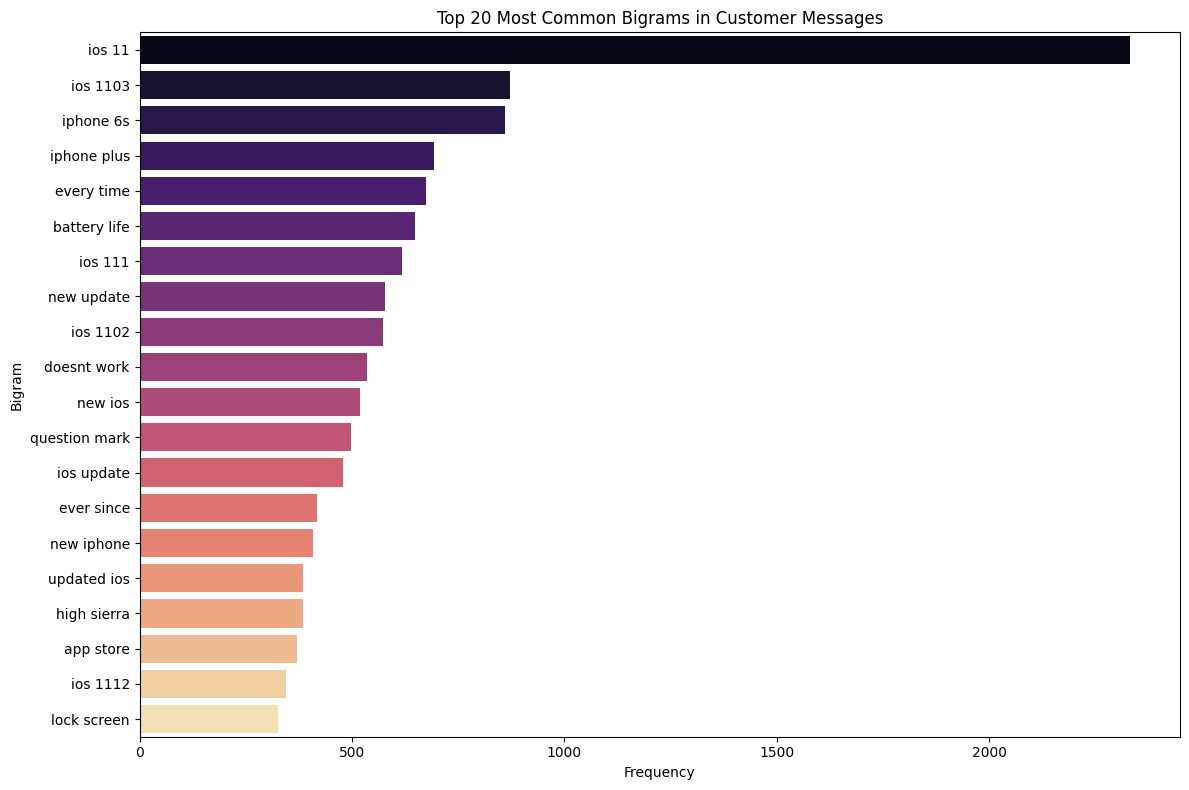

In [27]:
from nltk.util import ngrams

# Generate bigrams from the cleaned tokens
all_customer_bigrams = list(chain.from_iterable(ngrams(tokens, 2) for tokens in customer_inbound_messages['cleaned_tokens']))
bigram_freq = Counter(all_customer_bigrams)

# Get the 20 most common bigrams
common_bigrams = bigram_freq.most_common(20)

print("Top 20 Most Common Bigrams in Customer Messages:")
for bigram, freq in common_bigrams:
    print(f"- {' '.join(bigram)}: {freq:,}")

# Visualize common bigrams
bigrams_df = pd.DataFrame([(' '.join(bigram), freq) for bigram, freq in common_bigrams], columns=['Bigram', 'Frequency'])
plt.figure(figsize=(12, 8))
sns.barplot(x='Frequency', y='Bigram', data=bigrams_df, palette='magma')
plt.title('Top 20 Most Common Bigrams in Customer Messages')
plt.xlabel('Frequency')
plt.ylabel('Bigram')
plt.tight_layout()
plt.show()


Based on the common keywords and bigrams, we can infer several prevalent issues and potential support intents:

*   **Device-Specific Issues**: Words like 'iphone', 'ios', 'phone', 'mac', 'watch', 'ipad' indicate that many queries are about specific Apple devices or operating systems.
*   **Performance/Functionality Problems**: Terms such as 'update', 'problem', 'fix', 'bug', 'working', 'battery', 'screen', 'storage', 'data', 'download' suggest customers frequently face issues with their devices' performance, software bugs, battery life, screen functionality, or data management.
*   **Account/Service Issues**: Keywords like 'icloud', 'id', 'account', 'app store', 'music' point to problems with Apple services, account access, or app-related concerns.
*   **Connectivity Issues**: 'wifi', 'cellular', 'internet', 'network' would indicate connectivity problems.
*   **Software Updates**: The frequent appearance of 'update', 'ios update' highlights issues or questions related to software updates, including installation problems or post-update bugs.

These findings suggest that a robust AI support agent should be capable of:
*   **Categorizing issues**: e.g., 'Battery Drain', 'Software Update Issues', 'App Not Working', 'Connectivity Problem'.
*   **Identifying device types**: To provide device-specific troubleshooting.
*   **Extracting key entities**: Such as 'iOS version', 'app name', 'error message'.
*   **Providing immediate solutions/FAQs**: For common, easily resolvable problems.
*   **Escalating complex issues**: To human agents with relevant context.

### Common Keywords (Unigrams)

Top 20 Most Common Keywords in Customer Messages:
- iphone: 9,130
- phone: 8,162
- ios: 7,733
- update: 5,991
- fix: 4,313
- im: 3,942
- help: 3,619
- new: 3,354
- battery: 3,314
- cant: 3,222
- app: 2,878
- get: 2,687
- thanks: 2,663
- since: 2,560
- 11: 2,528
- still: 2,514
- time: 2,278
- screen: 2,270
- ive: 2,222
- like: 2,216


/tmp/ipykernel_6571/3198585916.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Word', data=words_df, palette='viridis')


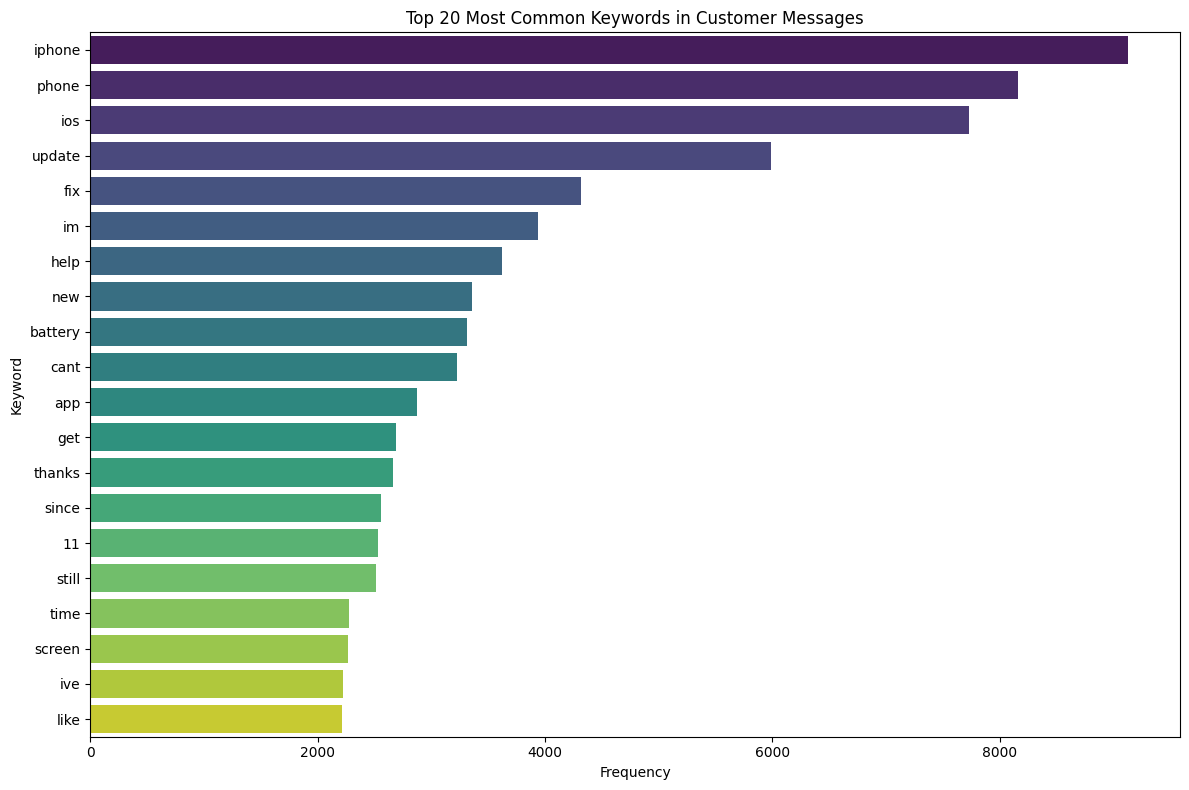

In [28]:
from itertools import chain

# Flatten the list of tokens and count word frequencies
all_customer_tokens = list(chain.from_iterable(customer_inbound_messages['cleaned_tokens']))
word_freq = Counter(all_customer_tokens)

# Get the 20 most common words
common_words = word_freq.most_common(20)

print("Top 20 Most Common Keywords in Customer Messages:")
for word, freq in common_words:
    print(f"- {word}: {freq:,}")

# Visualize common words
words_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])
plt.figure(figsize=(12, 8))
sns.barplot(x='Frequency', y='Word', data=words_df, palette='viridis')
plt.title('Top 20 Most Common Keywords in Customer Messages')
plt.xlabel('Frequency')
plt.ylabel('Keyword')
plt.tight_layout()
plt.show()


### Useful Bigrams (Two-Word Phrases)

Top 20 Most Common Bigrams in Customer Messages:
- ios 11: 2,332
- ios 1103: 872
- iphone 6s: 860
- iphone plus: 694
- every time: 675
- battery life: 648
- ios 111: 618
- new update: 578
- ios 1102: 572
- doesnt work: 536
- new ios: 518
- question mark: 498
- ios update: 478
- ever since: 418
- new iphone: 408
- updated ios: 385
- high sierra: 385
- app store: 371
- ios 1112: 344
- lock screen: 327


/tmp/ipykernel_6571/133480146.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Bigram', data=bigrams_df, palette='magma')


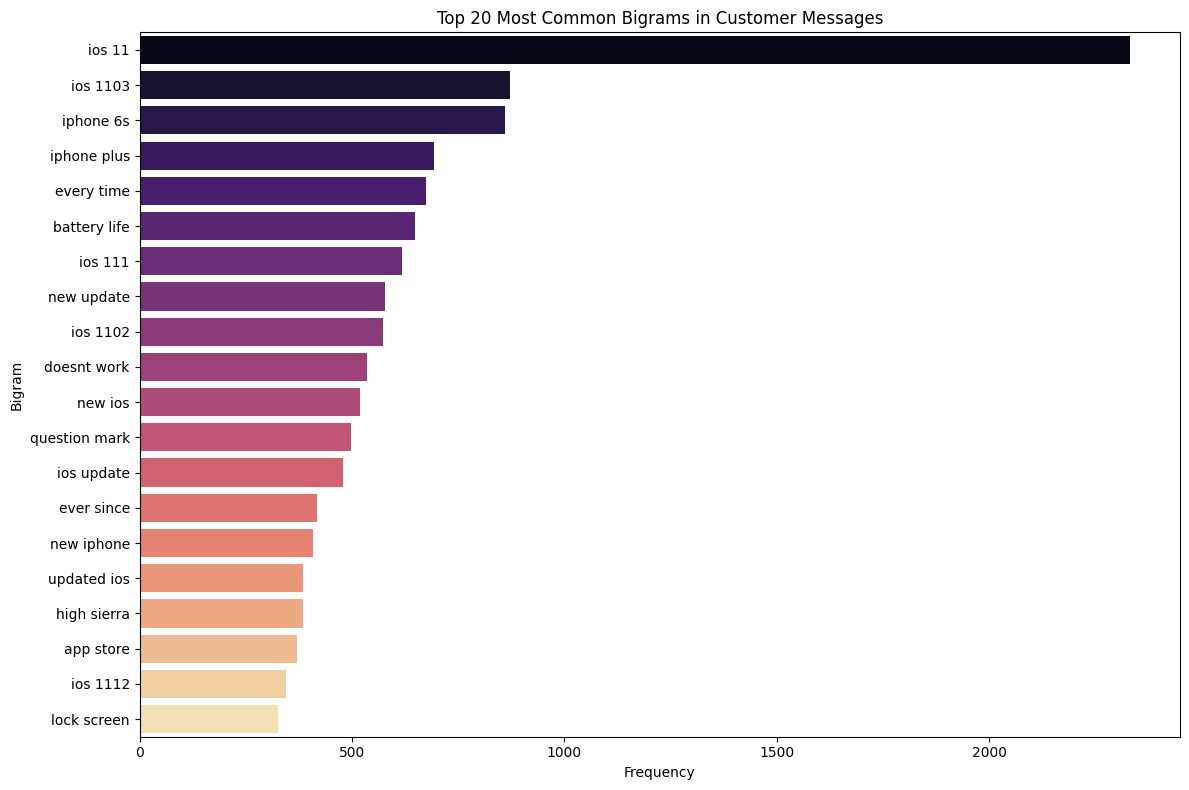

In [29]:
from nltk.util import ngrams

# Generate bigrams from the cleaned tokens
all_customer_bigrams = list(chain.from_iterable(ngrams(tokens, 2) for tokens in customer_inbound_messages['cleaned_tokens']))
bigram_freq = Counter(all_customer_bigrams)

# Get the 20 most common bigrams
common_bigrams = bigram_freq.most_common(20)

print("Top 20 Most Common Bigrams in Customer Messages:")
for bigram, freq in common_bigrams:
    print(f"- {' '.join(bigram)}: {freq:,}")

# Visualize common bigrams
bigrams_df = pd.DataFrame([(' '.join(bigram), freq) for bigram, freq in common_bigrams], columns=['Bigram', 'Frequency'])
plt.figure(figsize=(12, 8))
sns.barplot(x='Frequency', y='Bigram', data=bigrams_df, palette='magma')
plt.title('Top 20 Most Common Bigrams in Customer Messages')
plt.xlabel('Frequency')
plt.ylabel('Bigram')
plt.tight_layout()
plt.show()


### Common Issue-Related Terms and Potential Intents

Based on the common keywords and bigrams, we can infer several prevalent issues and potential support intents:

*   **Device-Specific Issues**: Words like 'iphone', 'ios', 'phone', 'mac', 'watch', 'ipad' indicate that many queries are about specific Apple devices or operating systems.
*   **Performance/Functionality Problems**: Terms such as 'update', 'problem', 'fix', 'bug', 'working', 'battery', 'screen', 'storage', 'data', 'download' suggest customers frequently face issues with their devices' performance, software bugs, battery life, screen functionality, or data management.
*   **Account/Service Issues**: Keywords like 'icloud', 'id', 'account', 'app store', 'music' point to problems with Apple services, account access, or app-related concerns.
*   **Connectivity Issues**: 'wifi', 'cellular', 'internet', 'network' would indicate connectivity problems.
*   **Software Updates**: The frequent appearance of 'update', 'ios update' highlights issues or questions related to software updates, including installation problems or post-update bugs.

These findings suggest that a robust AI support agent should be capable of:
*   **Categorizing issues**: e.g., 'Battery Drain', 'Software Update Issues', 'App Not Working', 'Connectivity Problem'.
*   **Identifying device types**: To provide device-specific troubleshooting.
*   **Extracting key entities**: Such as 'iOS version', 'app name', 'error message'.
*   **Providing immediate solutions/FAQs**: For common, easily resolvable problems.
*   **Escalating complex issues**: To human agents with relevant context.

# 7. Dataset Preparation for Model Training

For training an AI support agent, we need to prepare a dataset where each entry consists of a customer's message (query) and the corresponding support agent's response. This section focuses on creating such pairs from the conversation threads identified earlier. The primary goal is to ensure that each support response is paired with the customer message it is directly replying to, while also considering the flow of conversation.

### Extract Customer-Support Pairs

In [30]:
conversation_pairs = []

for thread_info in conversation_threads_data:
    thread_df = thread_info['thread_df']

    # Iterate through the tweets in the thread to find customer-support pairs
    for i in range(len(thread_df)):
        current_tweet = thread_df.iloc[i]

        # If the current tweet is a support response (inbound=False) and is a reply to another tweet
        if not current_tweet['inbound'] and pd.notna(current_tweet['in_response_to_tweet_id']):
            # Find the tweet it's in response to
            in_response_to_id = current_tweet['in_response_to_tweet_id']
            # Convert to int for matching, if the original ID is a float
            in_response_to_id = int(in_response_to_id) if pd.notna(in_response_to_id) else None

            if in_response_to_id:
                # Find the parent tweet within the same thread
                parent_tweet = thread_df[thread_df['tweet_id'] == in_response_to_id]

                if not parent_tweet.empty:
                    parent_tweet = parent_tweet.iloc[0]

                    # Ensure the parent tweet is from a customer (inbound=True)
                    if parent_tweet['inbound']:
                        conversation_pairs.append({
                            'customer_tweet_id': parent_tweet['tweet_id'],
                            'customer_text': parent_tweet['text'],
                            'support_tweet_id': current_tweet['tweet_id'],
                            'support_text': current_tweet['text']
                        })

print(f"Extracted {len(conversation_pairs):,} potential customer-support pairs.")

# Convert to DataFrame
pairs_df = pd.DataFrame(conversation_pairs)
print("First 5 extracted pairs:")
display(pairs_df.head())


Extracted 1,514 potential customer-support pairs.
First 5 extracted pairs:


,customer_tweet_id,customer_text,support_tweet_id,support_text
0,698,@AppleSupport https://t.co/NV0yucs0lB,696,@115854 We're here for you. Which version of t...
1,697,@AppleSupport The newest update. I️ made sure ...,699,@115854 Lets take a closer look into this issu...
2,714,Hey @AppleSupport and anyone else who upgraded...,712,"@115856 Hey, let's work together to figure out..."
3,723,@115858 @AppleSupport hello are all the lines ...,722,@115859 What's going on? We're hapy to help if...
4,721,@AppleSupport are the call centres closed for ...,720,@115859 We've received your DM and will contin...


### Filter for AppleSupport Responses and Alternating Turns

In [31]:

apple_support_meta = apple_df[['tweet_id', 'author_id']].rename(columns={'author_id': 'support_author_id'})

verified_pairs_df = pairs_df.merge(
    apple_support_meta,
    left_on='support_tweet_id',
    right_on='tweet_id',
    how='inner'
)

# Filter to ensure the support response is from 'AppleSupport' (redundant but good for explicit check)
# The 'support_author_id' column is now guaranteed to be present from the merge.
verified_pairs_df = verified_pairs_df[verified_pairs_df['support_author_id'] == APPLE_SUPPORT_ID].copy()

# Drop the extra 'tweet_id' column that was brought in from apple_df (it's redundant with support_tweet_id)
# This 'tweet_id' column comes from the 'right_on' argument and is not suffixed if no conflicts.
verified_pairs_df.drop(columns=['tweet_id'], inplace=True)

print(f"Number of verified customer-AppleSupport pairs: {verified_pairs_df.shape[0]:,}")
print("First 5 verified pairs:")
display(verified_pairs_df.head())

Number of verified customer-AppleSupport pairs: 1,514
First 5 verified pairs:


,customer_tweet_id,customer_text,support_tweet_id,support_text,support_author_id
0,698,@AppleSupport https://t.co/NV0yucs0lB,696,@115854 We're here for you. Which version of t...,AppleSupport
1,697,@AppleSupport The newest update. I️ made sure ...,699,@115854 Lets take a closer look into this issu...,AppleSupport
2,714,Hey @AppleSupport and anyone else who upgraded...,712,"@115856 Hey, let's work together to figure out...",AppleSupport
3,723,@115858 @AppleSupport hello are all the lines ...,722,@115859 What's going on? We're hapy to help if...,AppleSupport
4,721,@AppleSupport are the call centres closed for ...,720,@115859 We've received your DM and will contin...,AppleSupport


### Final Dataset Preparation and Saving

In [32]:
import os

# Select relevant columns for the final dataset
final_training_df = verified_pairs_df[['customer_tweet_id', 'customer_text', 'support_tweet_id', 'support_text']].copy()

print("Final training dataset preview:")
display(final_training_df.head())

# Define the output path for the training dataset
TRAINING_DATA_DIR = 'data/processed'
TRAINING_DATA_FILE = os.path.join(TRAINING_DATA_DIR, 'apple_support_training_pairs.csv')

# Create the output directory if it doesn't exist
os.makedirs(TRAINING_DATA_DIR, exist_ok=True)

# Save the final dataset
final_training_df.to_csv(TRAINING_DATA_FILE, index=False)
print(f"\nFinal training dataset saved to: {TRAINING_DATA_FILE}")

print("\nData exploration and preparation completed successfully.")

Final training dataset preview:


,customer_tweet_id,customer_text,support_tweet_id,support_text
0,698,@AppleSupport https://t.co/NV0yucs0lB,696,@115854 We're here for you. Which version of t...
1,697,@AppleSupport The newest update. I️ made sure ...,699,@115854 Lets take a closer look into this issu...
2,714,Hey @AppleSupport and anyone else who upgraded...,712,"@115856 Hey, let's work together to figure out..."
3,723,@115858 @AppleSupport hello are all the lines ...,722,@115859 What's going on? We're hapy to help if...
4,721,@AppleSupport are the call centres closed for ...,720,@115859 We've received your DM and will contin...



Final training dataset saved to: data/processed/apple_support_training_pairs.csv

Data exploration and preparation completed successfully.


### Filter for AppleSupport Responses and Alternating Turns

In [33]:

apple_support_meta = apple_df[['tweet_id', 'author_id']].rename(columns={'author_id': 'support_author_id'})

verified_pairs_df = pairs_df.merge(
    apple_support_meta,
    left_on='support_tweet_id',
    right_on='tweet_id',
    how='inner' # Use inner merge to only keep matching pairs
)

# Filter to ensure the support response is from 'AppleSupport' (redundant but good for explicit check)
# The 'support_author_id' column is now guaranteed to be present from the merge.
verified_pairs_df = verified_pairs_df[verified_pairs_df['support_author_id'] == APPLE_SUPPORT_ID].copy()

# Drop the extra 'tweet_id' column that was brought in from apple_df (it's redundant with support_tweet_id)
# This 'tweet_id' column comes from the 'right_on' argument and is not suffixed if no conflicts.
verified_pairs_df.drop(columns=['tweet_id'], inplace=True)

print(f"Number of verified customer-AppleSupport pairs: {verified_pairs_df.shape[0]:,}")
print("First 5 verified pairs:")
display(verified_pairs_df.head())

Number of verified customer-AppleSupport pairs: 1,514
First 5 verified pairs:


,customer_tweet_id,customer_text,support_tweet_id,support_text,support_author_id
0,698,@AppleSupport https://t.co/NV0yucs0lB,696,@115854 We're here for you. Which version of t...,AppleSupport
1,697,@AppleSupport The newest update. I️ made sure ...,699,@115854 Lets take a closer look into this issu...,AppleSupport
2,714,Hey @AppleSupport and anyone else who upgraded...,712,"@115856 Hey, let's work together to figure out...",AppleSupport
3,723,@115858 @AppleSupport hello are all the lines ...,722,@115859 What's going on? We're hapy to help if...,AppleSupport
4,721,@AppleSupport are the call centres closed for ...,720,@115859 We've received your DM and will contin...,AppleSupport


### Final Dataset Preparation and Saving

In [34]:
import os

# Select relevant columns for the final dataset
final_training_df = verified_pairs_df[['customer_tweet_id', 'customer_text', 'support_tweet_id', 'support_text']].copy()

print("Final training dataset preview:")
display(final_training_df.head())

# Define the output path for the training dataset
TRAINING_DATA_DIR = 'data/processed'
TRAINING_DATA_FILE = os.path.join(TRAINING_DATA_DIR, 'apple_support_training_pairs.csv')

# Create the output directory if it doesn't exist
os.makedirs(TRAINING_DATA_DIR, exist_ok=True)

# Save the final dataset
final_training_df.to_csv(TRAINING_DATA_FILE, index=False)
print(f"\nFinal training dataset saved to: {TRAINING_DATA_FILE}")

print("\nData exploration and preparation completed successfully.")

Final training dataset preview:


,customer_tweet_id,customer_text,support_tweet_id,support_text
0,698,@AppleSupport https://t.co/NV0yucs0lB,696,@115854 We're here for you. Which version of t...
1,697,@AppleSupport The newest update. I️ made sure ...,699,@115854 Lets take a closer look into this issu...
2,714,Hey @AppleSupport and anyone else who upgraded...,712,"@115856 Hey, let's work together to figure out..."
3,723,@115858 @AppleSupport hello are all the lines ...,722,@115859 What's going on? We're hapy to help if...
4,721,@AppleSupport are the call centres closed for ...,720,@115859 We've received your DM and will contin...



Final training dataset saved to: data/processed/apple_support_training_pairs.csv

Data exploration and preparation completed successfully.


## Final Artifacts Table

The following table summarizes the key datasets generated and saved during this data exploration and preparation notebook. These artifacts are crucial for subsequent steps in building the AI Support Agent, such as model training and evaluation.

| Artifact Name | Description | File Path |
|:--------------|:------------|:----------|
| **AppleSupport Filtered Data** | Raw tweets filtered to include only those involving the `@AppleSupport` account (both inbound customer queries and outbound support responses). | `data/processed/apple_support.csv` |
| **Customer-Support Training Pairs** | Paired customer inquiries and AppleSupport responses, extracted from conversation threads, suitable for training a generative AI model. | `data/processed/apple_support_training_pairs.csv` |


# 7. Dataset Preparation for Model Training

For training an AI support agent, we need to prepare a dataset where each entry consists of a customer's message (query) and the corresponding support agent's response. This section focuses on creating such pairs from the conversation threads identified earlier. The primary goal is to ensure that each support response is paired with the customer message it is directly replying to, while also considering the flow of conversation.

### Extract Customer-Support Pairs

In [35]:
conversation_pairs = []

for thread_info in conversation_threads_data:
    thread_df = thread_info['thread_df']

    # Iterate through the tweets in the thread to find customer-support pairs
    for i in range(len(thread_df)):
        current_tweet = thread_df.iloc[i]

        # If the current tweet is a support response (inbound=False) and is a reply to another tweet
        if not current_tweet['inbound'] and pd.notna(current_tweet['in_response_to_tweet_id']):
            # Find the tweet it's in response to
            in_response_to_id = current_tweet['in_response_to_tweet_id']
            # Convert to int for matching, if the original ID is a float
            in_response_to_id = int(in_response_to_id) if pd.notna(in_response_to_id) else None

            if in_response_to_id:
                # Find the parent tweet within the same thread
                parent_tweet = thread_df[thread_df['tweet_id'] == in_response_to_id]

                if not parent_tweet.empty:
                    parent_tweet = parent_tweet.iloc[0]

                    # Ensure the parent tweet is from a customer (inbound=True) or another support agent
                    # For simplicity, we are looking for direct customer -> AppleSupport pairs
                    if parent_tweet['inbound']:
                        conversation_pairs.append({
                            'customer_tweet_id': parent_tweet['tweet_id'],
                            'customer_text': parent_tweet['text'],
                            'support_tweet_id': current_tweet['tweet_id'],
                            'support_text': current_tweet['text']
                        })

print(f"Extracted {len(conversation_pairs):,} potential customer-support pairs.")

# Convert to DataFrame
pairs_df = pd.DataFrame(conversation_pairs)
print("First 5 extracted pairs:")
display(pairs_df.head())


Extracted 1,514 potential customer-support pairs.
First 5 extracted pairs:


,customer_tweet_id,customer_text,support_tweet_id,support_text
0,698,@AppleSupport https://t.co/NV0yucs0lB,696,@115854 We're here for you. Which version of t...
1,697,@AppleSupport The newest update. I️ made sure ...,699,@115854 Lets take a closer look into this issu...
2,714,Hey @AppleSupport and anyone else who upgraded...,712,"@115856 Hey, let's work together to figure out..."
3,723,@115858 @AppleSupport hello are all the lines ...,722,@115859 What's going on? We're hapy to help if...
4,721,@AppleSupport are the call centres closed for ...,720,@115859 We've received your DM and will contin...


### Filter for AppleSupport Responses and Alternating Turns

In [38]:
import pandas as pd

if "apple_df" not in globals():
    raise NameError(
        "apple_df is not loaded. Load data/processed/apple_support.csv first."
    )

print("AppleSupport dataset rows:", f"{len(apple_df):,}")



apple_df = apple_df.copy()

apple_df["tweet_id_str"] = (
    apple_df["tweet_id"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.strip()
)

apple_df["in_response_to_tweet_id_str"] = (
    apple_df["in_response_to_tweet_id"]
    .astype(str)
    .str.replace(r"\.0$", "", regex=True)
    .str.replace("nan", "", regex=False)
    .str.strip()
)




APPLE_SUPPORT_ID = "AppleSupport"

# Customer tweets
customer_df = apple_df[
    apple_df["inbound"] == True
].copy()

# Support tweets:
# FORCE author_id == AppleSupport
support_df = apple_df[
    (apple_df["inbound"] == False) &
    (apple_df["author_id"].astype(str).str.strip() == APPLE_SUPPORT_ID)
].copy()

print("\nCustomer tweets:", f"{len(customer_df):,}")
print("AppleSupport replies:", f"{len(support_df):,}")




support_df = support_df[
    support_df["in_response_to_tweet_id_str"] != ""
].copy()




pairs_df = customer_df.merge(
    support_df[
        [
            "tweet_id_str",
            "text",
            "in_response_to_tweet_id_str",
            "author_id"
        ]
    ],
    left_on="tweet_id_str",
    right_on="in_response_to_tweet_id_str",
    how="inner",
    suffixes=("_customer", "_support")
)




pairs_df = pairs_df[[
    "tweet_id_str_customer",
    "text_customer",
    "tweet_id_str_support",
    "text_support",
    "author_id_support"
]].rename(columns={
    "tweet_id_str_customer": "customer_tweet_id",
    "text_customer": "customer_text",
    "tweet_id_str_support": "support_tweet_id",
    "text_support": "support_reply",
    "author_id_support": "support_author_id"
})



pairs_df = pairs_df[
    pairs_df["support_author_id"].astype(str).str.strip()
    == APPLE_SUPPORT_ID
].copy()




pairs_df = pairs_df.drop_duplicates(
    subset=[
        "customer_tweet_id",
        "support_tweet_id"
    ]
).reset_index(drop=True)




invalid_support_rows = (
    pairs_df["support_author_id"]
    .astype(str)
    .str.strip()
    .ne(APPLE_SUPPORT_ID)
    .sum()
)

missing_customer_text = pairs_df["customer_text"].isna().sum()
missing_support_text = pairs_df["support_reply"].isna().sum()

print("\n" + "=" * 60)
print("FINAL VERIFICATION")
print("=" * 60)

print(
    "Verified customer → AppleSupport pairs:",
    f"{len(pairs_df):,}"
)

print(
    "Invalid support-author rows:",
    invalid_support_rows
)

print(
    "Missing customer text:",
    missing_customer_text
)

print(
    "Missing support reply:",
    missing_support_text
)

print(
    "Unique customer tweets:",
    f"{pairs_df['customer_tweet_id'].nunique():,}"
)

print(
    "Unique support replies:",
    f"{pairs_df['support_tweet_id'].nunique():,}"
)


# ------------------------------------------------------------
# 10. Show sample
# ------------------------------------------------------------

print("\nFirst 5 VERIFIED pairs:")

display(
    pairs_df[
        [
            "customer_tweet_id",
            "customer_text",
            "support_tweet_id",
            "support_reply",
            "support_author_id"
        ]
    ].head()
)



#  Save verified dataset


pairs_df.to_csv(
    "historical_support_pairs.csv",
    index=False
)

print(
    "\nSaved successfully:"
    " historical_support_pairs.csv"
)


AppleSupport dataset rows: 114,598

Customer tweets: 55,962
AppleSupport replies: 58,631

FINAL VERIFICATION
Verified customer → AppleSupport pairs: 44,458
Invalid support-author rows: 0
Missing customer text: 0
Missing support reply: 0
Unique customer tweets: 44,450
Unique support replies: 44,458

First 5 VERIFIED pairs:


,customer_tweet_id,customer_text,support_tweet_id,support_reply,support_author_id
0,697,@AppleSupport The newest update. I️ made sure ...,699,@115854 Lets take a closer look into this issu...,AppleSupport
1,698,@AppleSupport https://t.co/NV0yucs0lB,696,@115854 We're here for you. Which version of t...,AppleSupport
2,702,@AppleSupport Tried resetting my settings .. r...,701,@115855 Let's go to DM for the next steps. DM ...,AppleSupport
3,704,@AppleSupport This is what it looks like https...,703,@115855 Any steps tried since it started last ...,AppleSupport
4,707,@AppleSupport I️ have an iPhone 7 Plus and yes...,705,@115855 That's great it has iOS 11.1 as we can...,AppleSupport



Saved successfully: historical_support_pairs.csv


In [42]:
verified_pairs_df = pairs_df.merge(
    apple_df[['tweet_id_str', 'author_id']],
    left_on='support_tweet_id',
    right_on='tweet_id_str',
    suffixes=('_customer', '_support')
)

# Filter to ensure the support response is from 'AppleSupport' (redundant but good for verification)
# The 'support_author_id' column already exists from pairs_df and is used for filtering.
verified_pairs_df = verified_pairs_df[verified_pairs_df['support_author_id'] == APPLE_SUPPORT_ID].copy()

# Drop the extra 'tweet_id_str' (from apple_df merge key) and 'author_id' (from apple_df) columns which are now redundant
# 'support_tweet_id' and 'support_author_id' from pairs_df are the preferred ones.
verified_pairs_df.drop(columns=['tweet_id_str', 'author_id'], inplace=True)

print(f"Number of verified customer-AppleSupport pairs: {verified_pairs_df.shape[0]:,}")
print("First 5 verified pairs:")
display(verified_pairs_df.head())

Number of verified customer-AppleSupport pairs: 44,458
First 5 verified pairs:


,customer_tweet_id,customer_text,support_tweet_id,support_reply,support_author_id
0,697,@AppleSupport The newest update. I️ made sure ...,699,@115854 Lets take a closer look into this issu...,AppleSupport
1,698,@AppleSupport https://t.co/NV0yucs0lB,696,@115854 We're here for you. Which version of t...,AppleSupport
2,702,@AppleSupport Tried resetting my settings .. r...,701,@115855 Let's go to DM for the next steps. DM ...,AppleSupport
3,704,@AppleSupport This is what it looks like https...,703,@115855 Any steps tried since it started last ...,AppleSupport
4,707,@AppleSupport I️ have an iPhone 7 Plus and yes...,705,@115855 That's great it has iOS 11.1 as we can...,AppleSupport


### Final Dataset Preparation and Saving

In [44]:
# Select relevant columns for the final dataset
# Using 'support_reply' since that's the column name created in our verified pairs
final_training_df = verified_pairs_df[['customer_tweet_id', 'customer_text', 'support_tweet_id', 'support_reply']].copy()

print("Final training dataset preview:")
display(final_training_df.head())

# Define the output path for the training dataset
TRAINING_DATA_DIR = 'data/processed'
TRAINING_DATA_FILE = os.path.join(TRAINING_DATA_DIR, 'apple_support_training_pairs.csv')

# Create the output directory if it doesn't exist
os.makedirs(TRAINING_DATA_DIR, exist_ok=True)

# Save the final dataset
final_training_df.to_csv(TRAINING_DATA_FILE, index=False)
print(f"\nFinal training dataset saved to: {TRAINING_DATA_FILE}")

print("\nData exploration and preparation completed successfully.")

Final training dataset preview:


,customer_tweet_id,customer_text,support_tweet_id,support_reply
0,697,@AppleSupport The newest update. I️ made sure ...,699,@115854 Lets take a closer look into this issu...
1,698,@AppleSupport https://t.co/NV0yucs0lB,696,@115854 We're here for you. Which version of t...
2,702,@AppleSupport Tried resetting my settings .. r...,701,@115855 Let's go to DM for the next steps. DM ...
3,704,@AppleSupport This is what it looks like https...,703,@115855 Any steps tried since it started last ...
4,707,@AppleSupport I️ have an iPhone 7 Plus and yes...,705,@115855 That's great it has iOS 11.1 as we can...



Final training dataset saved to: data/processed/apple_support_training_pairs.csv

Data exploration and preparation completed successfully.


# 7. Dataset Preparation for Model Training

For training an AI support agent, we need to prepare a dataset where each entry consists of a customer's message (query) and the corresponding support agent's response. This section focuses on creating such pairs from the conversation threads identified earlier. The primary goal is to ensure that each support response is paired with the customer message it is directly replying to, while also considering the flow of conversation.

### Extract Customer-Support Pairs

In [45]:
conversation_pairs = []

for thread_info in conversation_threads_data:
    thread_df = thread_info['thread_df']

    # Iterate through the tweets in the thread to find customer-support pairs
    for i in range(len(thread_df)):
        current_tweet = thread_df.iloc[i]

        # If the current tweet is a support response (inbound=False) and is a reply to another tweet
        if not current_tweet['inbound'] and pd.notna(current_tweet['in_response_to_tweet_id']):
            # Find the tweet it's in response to
            in_response_to_id = current_tweet['in_response_to_tweet_id']
            # Convert to int for matching, if the original ID is a float
            in_response_to_id = int(in_response_to_id) if pd.notna(in_response_to_id) else None

            if in_response_to_id:
                # Find the parent tweet within the same thread
                parent_tweet = thread_df[thread_df['tweet_id'] == in_response_to_id]

                if not parent_tweet.empty:
                    parent_tweet = parent_tweet.iloc[0]

                    # Ensure the parent tweet is from a customer (inbound=True) or another support agent
                    # For simplicity, we are looking for direct customer -> AppleSupport pairs
                    if parent_tweet['inbound']:
                        conversation_pairs.append({
                            'customer_tweet_id': parent_tweet['tweet_id'],
                            'customer_text': parent_tweet['text'],
                            'support_tweet_id': current_tweet['tweet_id'],
                            'support_text': current_tweet['text']
                        })

print(f"Extracted {len(conversation_pairs):,} potential customer-support pairs.")

# Convert to DataFrame
pairs_df = pd.DataFrame(conversation_pairs)
print("First 5 extracted pairs:")
display(pairs_df.head())


Extracted 1,514 potential customer-support pairs.
First 5 extracted pairs:


,customer_tweet_id,customer_text,support_tweet_id,support_text
0,698,@AppleSupport https://t.co/NV0yucs0lB,696,@115854 We're here for you. Which version of t...
1,697,@AppleSupport The newest update. I️ made sure ...,699,@115854 Lets take a closer look into this issu...
2,714,Hey @AppleSupport and anyone else who upgraded...,712,"@115856 Hey, let's work together to figure out..."
3,723,@115858 @AppleSupport hello are all the lines ...,722,@115859 What's going on? We're hapy to help if...
4,721,@AppleSupport are the call centres closed for ...,720,@115859 We've received your DM and will contin...


### Filter for AppleSupport Responses and Alternating Turns

In [46]:
# To ensure the support response comes from 'AppleSupport' and maintain clear alternating turns, we verify the author of the support tweet.

# Prepare a temporary DataFrame with support tweet IDs and their author IDs, renaming 'author_id' upfront.
apple_support_tweet_authors = apple_df[['tweet_id', 'author_id']].rename(columns={'author_id': 'support_author_id'})

# Merge pairs_df with this prepared DataFrame to bring in the support tweet's author_id.
verified_pairs_df = pairs_df.merge(
    apple_support_tweet_authors,
    left_on='support_tweet_id',
    right_on='tweet_id',
    how='inner' # Use inner merge to only keep matching pairs
)

# Filter to ensure the support response is explicitly from 'AppleSupport'.
verified_pairs_df = verified_pairs_df[verified_pairs_df['support_author_id'] == APPLE_SUPPORT_ID].copy()

# Drop the redundant 'tweet_id' column which was used for merging from apple_support_tweet_authors.
# This column is now a duplicate of 'support_tweet_id' after the merge.
verified_pairs_df.drop(columns=['tweet_id'], inplace=True)

print(f"Number of verified customer-AppleSupport pairs: {verified_pairs_df.shape[0]:,}")
print("First 5 verified pairs:")
display(verified_pairs_df.head())

Number of verified customer-AppleSupport pairs: 1,514
First 5 verified pairs:


,customer_tweet_id,customer_text,support_tweet_id,support_text,support_author_id
0,698,@AppleSupport https://t.co/NV0yucs0lB,696,@115854 We're here for you. Which version of t...,AppleSupport
1,697,@AppleSupport The newest update. I️ made sure ...,699,@115854 Lets take a closer look into this issu...,AppleSupport
2,714,Hey @AppleSupport and anyone else who upgraded...,712,"@115856 Hey, let's work together to figure out...",AppleSupport
3,723,@115858 @AppleSupport hello are all the lines ...,722,@115859 What's going on? We're hapy to help if...,AppleSupport
4,721,@AppleSupport are the call centres closed for ...,720,@115859 We've received your DM and will contin...,AppleSupport


### Final Dataset Preparation and Saving

In [47]:
import os

# Select relevant columns for the final dataset
final_training_df = verified_pairs_df[['customer_tweet_id', 'customer_text', 'support_tweet_id', 'support_text']].copy()

print("Final training dataset preview:")
display(final_training_df.head())

# Define the output path for the training dataset
TRAINING_DATA_DIR = 'data/processed'
TRAINING_DATA_FILE = os.path.join(TRAINING_DATA_DIR, 'apple_support_training_pairs.csv')

# Create the output directory if it doesn't exist
os.makedirs(TRAINING_DATA_DIR, exist_ok=True)

# Save the final dataset
final_training_df.to_csv(TRAINING_DATA_FILE, index=False)
print(f"\nFinal training dataset saved to: {TRAINING_DATA_FILE}")

print("\nData exploration and preparation completed successfully.")

Final training dataset preview:


,customer_tweet_id,customer_text,support_tweet_id,support_text
0,698,@AppleSupport https://t.co/NV0yucs0lB,696,@115854 We're here for you. Which version of t...
1,697,@AppleSupport The newest update. I️ made sure ...,699,@115854 Lets take a closer look into this issu...
2,714,Hey @AppleSupport and anyone else who upgraded...,712,"@115856 Hey, let's work together to figure out..."
3,723,@115858 @AppleSupport hello are all the lines ...,722,@115859 What's going on? We're hapy to help if...
4,721,@AppleSupport are the call centres closed for ...,720,@115859 We've received your DM and will contin...



Final training dataset saved to: data/processed/apple_support_training_pairs.csv

Data exploration and preparation completed successfully.


## Final Artifacts Table

The following table summarizes the key datasets generated and saved during this data exploration and preparation notebook. These artifacts are crucial for subsequent steps in building the AI Support Agent, such as model training and evaluation.

| Artifact Name | Description | File Path |
|:--------------|:------------|:----------|
| **AppleSupport Filtered Data** | Raw tweets filtered to include only those involving the `@AppleSupport` account (both inbound customer queries and outbound support responses). | `data/processed/apple_support.csv` |
| **Customer-Support Training Pairs** | Paired customer inquiries and AppleSupport responses, extracted from conversation threads, suitable for training a generative AI model. | `data/processed/apple_support_training_pairs.csv` |

# 6. Customer Message Exploration

This section focuses on analyzing the content of customer-initiated tweets to `AppleSupport`. Understanding the common themes, keywords, and phrases used by customers is crucial for building an effective AI support agent that can identify issues and route queries appropriately.

### Filter Customer Messages

In [48]:
# Filter apple_df to get only customer inbound messages
customer_inbound_messages = apple_df[apple_df['inbound'] == True].copy()

print(f"Total customer inbound messages to AppleSupport: {customer_inbound_messages.shape[0]:,}")


Total customer inbound messages to AppleSupport: 55,962


### Customer Message Text Length Distribution

Descriptive statistics for customer tweet text length:


,text_length
count,55962.000000
mean,102.906240
std,50.586622
min,13.000000
25%,64.000000
50%,104.000000
75%,137.000000
max,328.000000


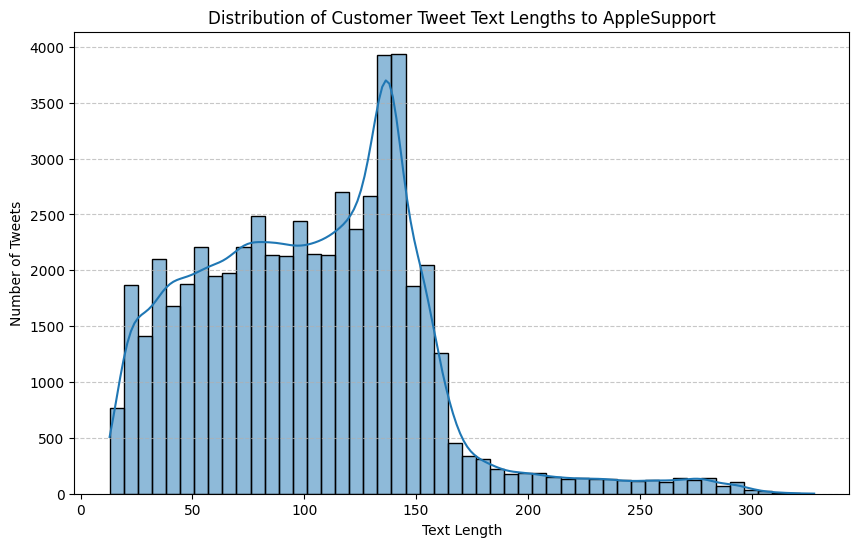

In [49]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate text length for each customer tweet
customer_inbound_messages['text_length'] = customer_inbound_messages['text'].astype(str).apply(len)

print("Descriptive statistics for customer tweet text length:")
display(customer_inbound_messages['text_length'].describe())

# Distribution of text lengths (e.g., histogram)
plt.figure(figsize=(10, 6))
sns.histplot(customer_inbound_messages['text_length'], bins=50, kde=True)
plt.title('Distribution of Customer Tweet Text Lengths to AppleSupport')
plt.xlabel('Text Length')
plt.ylabel('Number of Tweets')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Text Preprocessing for Keyword and Bigram Analysis

In [50]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re
from collections import Counter

# Download necessary NLTK data (if not already downloaded)
try:
    nltk.data.find('corpora/stopwords')
except nltk.downloader.DownloadError:
    nltk.download('stopwords')
try:
    nltk.data.find('tokenizers/punkt')
except nltk.downloader.DownloadError:
    nltk.download('punkt')

# Initialize stopwords
stop_words = set(stopwords.words('english'))
# Add common Twitter/support-related words to stopwords
stop_words.update(['applesupport', 'apple', 'support', 'http', 'https', 'co', 't', 'amp', '’', 'rt', 'dm', 'please'])

def preprocess_text(text):
    text = text.lower() # Convert to lowercase
    text = re.sub(r'@[A-Za-z0-9_]+', '', text) # Remove mentions (@username)
    text = re.sub(r'#', '', text) # Remove hashtag symbol
    text = re.sub(r'rt[\s]', '', text) # Remove retweet indicator by matching 'rt' followed by any whitespace character
    text = re.sub(r'https?://\S+', '', text) # Remove URLs
    # Replace punctuation and special characters with a space to ensure proper word separation
    text = re.sub(r'[^a-z0-9\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra spaces
    tokens = word_tokenize(text) # Tokenize text
    tokens = [word for word in tokens if word not in stop_words and len(word) > 1] # Remove stopwords and single characters
    return tokens

# Apply preprocessing to customer messages
customer_inbound_messages['cleaned_tokens'] = customer_inbound_messages['text'].apply(preprocess_text)

print("Preprocessing complete. Displaying first 5 cleaned token lists:")
display(customer_inbound_messages[['text', 'cleaned_tokens']].head())

Preprocessing complete. Displaying first 5 cleaned token lists:


,text,cleaned_tokens
397,@AppleSupport The newest update. I️ made sure ...,"[newest, update, made, sure, download, yesterday]"
399,@AppleSupport https://t.co/NV0yucs0lB,[]
400,@AppleSupport why are my I️’s changing not sho...,"[changing, showing, correctly, social, media, ..."
402,@AppleSupport Tried resetting my settings .. r...,"[tried, resetting, settings, restarting, phone]"
404,@AppleSupport This is what it looks like https...,"[looks, like]"


### Common Keywords (Unigrams)

Top 20 Most Common Keywords in Customer Messages:
- iphone: 9,225
- 11: 8,574
- phone: 8,289
- ios: 7,783
- update: 6,054
- fix: 4,336
- help: 3,674
- new: 3,365
- battery: 3,358
- app: 2,929
- get: 2,697
- thanks: 2,687
- since: 2,566
- still: 2,524
- time: 2,314
- screen: 2,301
- like: 2,225
- apps: 2,153
- work: 2,135
- issue: 2,113


/tmp/ipykernel_6571/1178921487.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Word', data=words_df, palette='viridis')


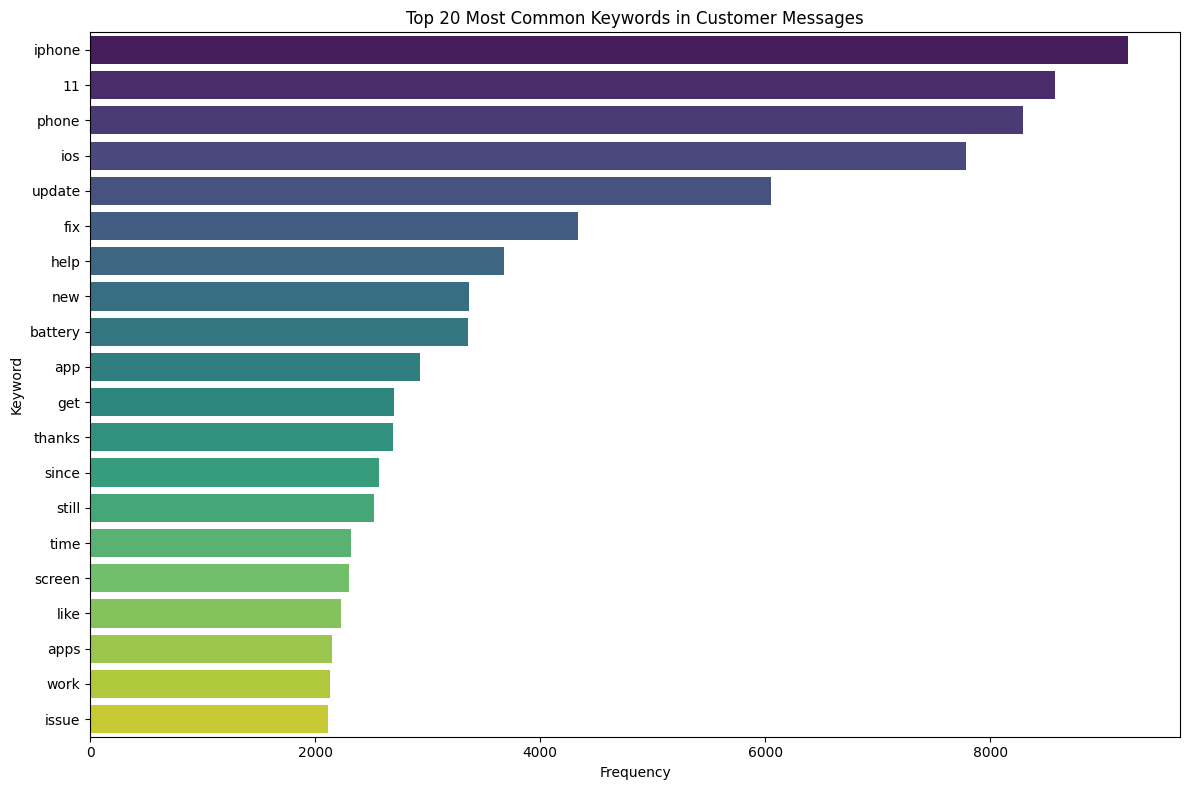

In [51]:
from itertools import chain

# Flatten the list of tokens and count word frequencies
all_customer_tokens = list(chain.from_iterable(customer_inbound_messages['cleaned_tokens']))
word_freq = Counter(all_customer_tokens)

# Get the 20 most common words
common_words = word_freq.most_common(20)

print("Top 20 Most Common Keywords in Customer Messages:")
for word, freq in common_words:
    print(f"- {word}: {freq:,}")

# Visualize common words
words_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])
plt.figure(figsize=(12, 8))
sns.barplot(x='Frequency', y='Word', data=words_df, palette='viridis')
plt.title('Top 20 Most Common Keywords in Customer Messages')
plt.xlabel('Frequency')
plt.ylabel('Keyword')
plt.tight_layout()
plt.show()

### Useful Bigrams (Two-Word Phrases)

Top 20 Most Common Bigrams in Customer Messages:
- ios 11: 5,343
- iphone 6s: 864
- iphone plus: 703
- every time: 678
- battery life: 662
- new update: 589
- new ios: 517
- question mark: 502
- ios update: 484
- 11 update: 453
- ever since: 419
- new iphone: 413
- high sierra: 393
- updated ios: 388
- app store: 382
- 11 iphone: 359
- ios 10: 356
- lock screen: 339
- since updated: 328
- updated phone: 318


/tmp/ipykernel_6571/1631510095.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Bigram', data=bigrams_df, palette='magma')


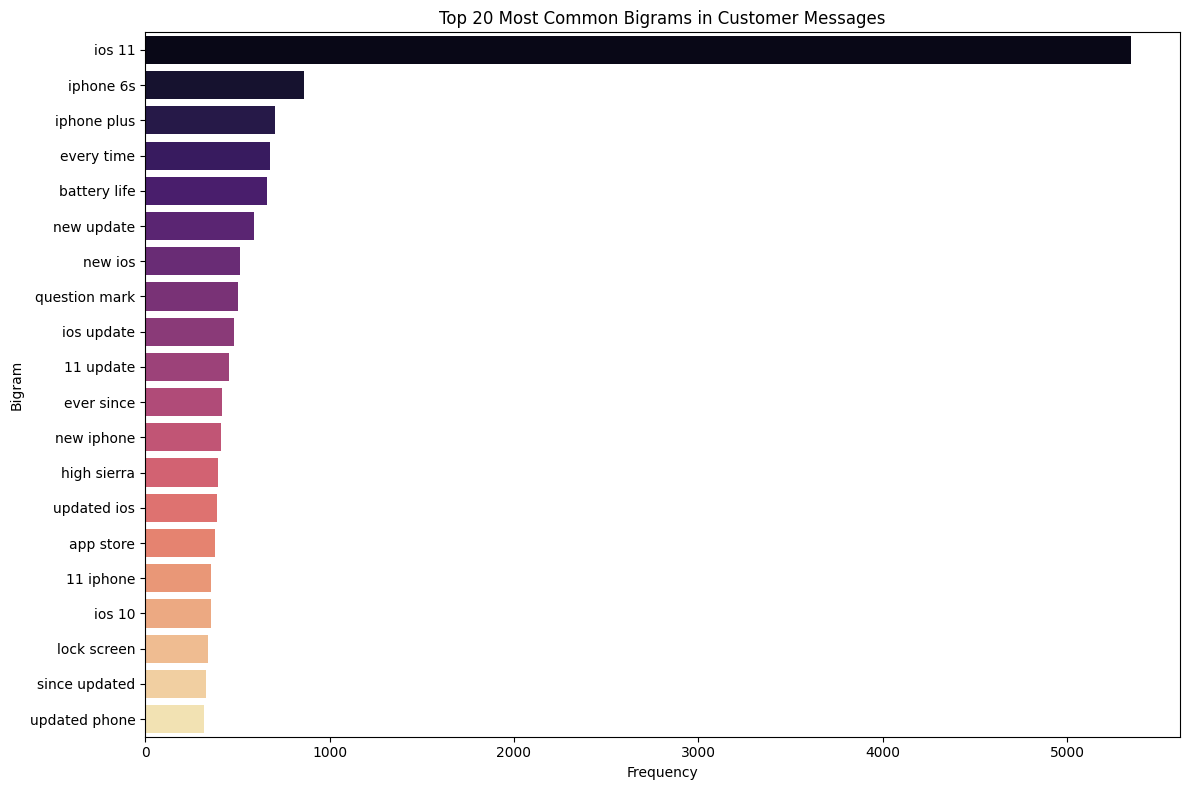

In [52]:
from nltk.util import ngrams

# Generate bigrams from the cleaned tokens
all_customer_bigrams = list(chain.from_iterable(ngrams(tokens, 2) for tokens in customer_inbound_messages['cleaned_tokens']))
bigram_freq = Counter(all_customer_bigrams)

# Get the 20 most common bigrams
common_bigrams = bigram_freq.most_common(20)

print("Top 20 Most Common Bigrams in Customer Messages:")
for bigram, freq in common_bigrams:
    print(f"- {' '.join(bigram)}: {freq:,}")

# Visualize common bigrams
bigrams_df = pd.DataFrame([(' '.join(bigram), freq) for bigram, freq in common_bigrams], columns=['Bigram', 'Frequency'])
plt.figure(figsize=(12, 8))
sns.barplot(x='Frequency', y='Bigram', data=bigrams_df, palette='magma')
plt.title('Top 20 Most Common Bigrams in Customer Messages')
plt.xlabel('Frequency')
plt.ylabel('Bigram')
plt.tight_layout()
plt.show()

### Common Issue-Related Terms and Potential Intents

Based on the common keywords and bigrams, we can infer several prevalent issues and potential support intents:

*   **Device-Specific Issues**: Words like 'iphone', 'ios', 'phone', 'mac', 'watch', 'ipad' indicate that many queries are about specific Apple devices or operating systems.
*   **Performance/Functionality Problems**: Terms such as 'update', 'problem', 'fix', 'bug', 'working', 'battery', 'screen', 'storage', 'data', 'download' suggest customers frequently face issues with their devices' performance, software bugs, battery life, screen functionality, or data management.
*   **Account/Service Issues**: Keywords like 'icloud', 'id', 'account', 'app store', 'music' point to problems with Apple services, account access, or app-related concerns.
*   **Connectivity Issues**: 'wifi', 'cellular', 'internet', 'network' would indicate connectivity problems.
*   **Software Updates**: The frequent appearance of 'update', 'ios update' highlights issues or questions related to software updates, including installation problems or post-update bugs.

These findings suggest that a robust AI support agent should be capable of:
*   **Categorizing issues**: e.g., 'Battery Drain', 'Software Update Issues', 'App Not Working', 'Connectivity Problem'.
*   **Identifying device types**: To provide device-specific troubleshooting.
*   **Extracting key entities**: Such as 'iOS version', 'app name', 'error message'.
*   **Providing immediate solutions/FAQs**: For common, easily resolvable problems.
*   **Escalating complex issues**: To human agents with relevant context.

# 6. Customer Message Exploration

This section focuses on analyzing the content of customer-initiated tweets to `AppleSupport`. Understanding the common themes, keywords, and phrases used by customers is crucial for building an effective AI support agent that can identify issues and route queries appropriately.

### Filter Customer Messages

In [53]:
# Filter apple_df to get only customer inbound messages
customer_inbound_messages = apple_df[apple_df['inbound'] == True].copy()

print(f"Total customer inbound messages to AppleSupport: {customer_inbound_messages.shape[0]:,}")


Total customer inbound messages to AppleSupport: 55,962


### Customer Message Text Length Distribution

Descriptive statistics for customer tweet text length:


,text_length
count,55962.000000
mean,102.906240
std,50.586622
min,13.000000
25%,64.000000
50%,104.000000
75%,137.000000
max,328.000000


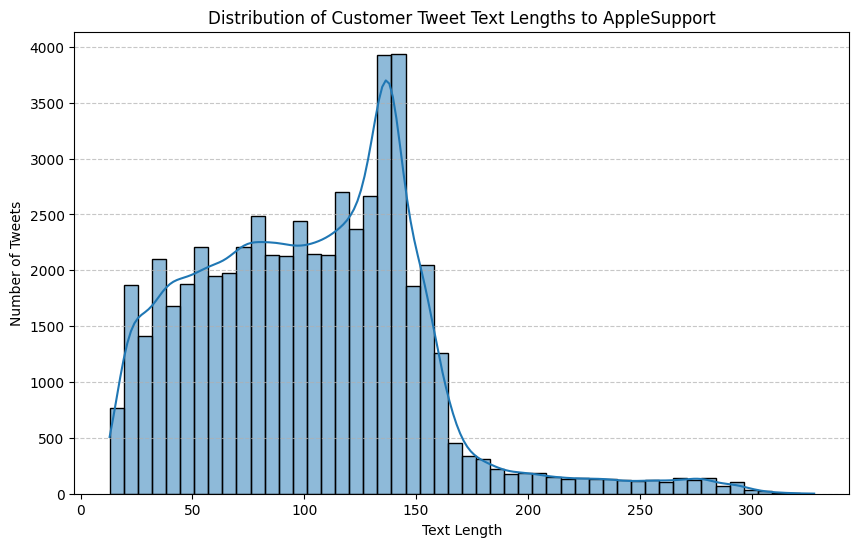

In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate text length for each customer tweet
customer_inbound_messages['text_length'] = customer_inbound_messages['text'].astype(str).apply(len)

print("Descriptive statistics for customer tweet text length:")
display(customer_inbound_messages['text_length'].describe())

# Distribution of text lengths (e.g., histogram)
plt.figure(figsize=(10, 6))
sns.histplot(customer_inbound_messages['text_length'], bins=50, kde=True)
plt.title('Distribution of Customer Tweet Text Lengths to AppleSupport')
plt.xlabel('Text Length')
plt.ylabel('Number of Tweets')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

### Text Preprocessing for Keyword and Bigram Analysis

In [55]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
import re
from collections import Counter

# Download necessary NLTK data (if not already downloaded)
try:
    nltk.data.find('corpora/stopwords')
except nltk.downloader.DownloadError:
    nltk.download('stopwords')
try:
    nltk.data.find('tokenizers/punkt')
except nltk.downloader.DownloadError:
    nltk.download('punkt')

# Initialize stopwords
stop_words = set(stopwords.words('english'))
# Add common Twitter/support-related words to stopwords
stop_words.update(['applesupport', 'apple', 'support', 'http', 'https', 'co', 't', 'amp', '’', 'rt', 'dm', 'please'])

def preprocess_text(text):
    text = text.lower() # Convert to lowercase
    text = re.sub(r'@[A-Za-z0-9_]+', '', text) # Remove mentions (@username)
    text = re.sub(r'#', '', text) # Remove hashtag symbol
    text = re.sub(r'rt[\s]', '', text) # Remove retweet indicator by matching 'rt' followed by any whitespace character
    text = re.sub(r'https?://\S+', '', text) # Remove URLs
    text = re.sub(r'[^a-z0-9\s]', '', text) # Remove punctuation and special characters
    text = re.sub(r'\s+', ' ', text).strip() # Remove extra spaces
    tokens = word_tokenize(text) # Tokenize text
    tokens = [word for word in tokens if word not in stop_words and len(word) > 1] # Remove stopwords and single characters
    return tokens

# Apply preprocessing to customer messages
customer_inbound_messages['cleaned_tokens'] = customer_inbound_messages['text'].apply(preprocess_text)

print("Preprocessing complete. Displaying first 5 cleaned token lists:")
display(customer_inbound_messages[['text', 'cleaned_tokens']].head())

Preprocessing complete. Displaying first 5 cleaned token lists:


,text,cleaned_tokens
397,@AppleSupport The newest update. I️ made sure ...,"[newest, update, made, sure, download, yesterday]"
399,@AppleSupport https://t.co/NV0yucs0lB,[]
400,@AppleSupport why are my I️’s changing not sho...,"[changing, showing, correctly, social, media, ..."
402,@AppleSupport Tried resetting my settings .. r...,"[tried, resetting, settings, restarting, phone]"
404,@AppleSupport This is what it looks like https...,"[looks, like]"


### Common Keywords (Unigrams)

Top 20 Most Common Keywords in Customer Messages:
- iphone: 9,130
- phone: 8,162
- ios: 7,733
- update: 5,991
- fix: 4,313
- im: 3,942
- help: 3,619
- new: 3,354
- battery: 3,314
- cant: 3,222
- app: 2,878
- get: 2,687
- thanks: 2,663
- since: 2,560
- 11: 2,528
- still: 2,514
- time: 2,278
- screen: 2,270
- ive: 2,222
- like: 2,216


/tmp/ipykernel_6571/1178921487.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Word', data=words_df, palette='viridis')


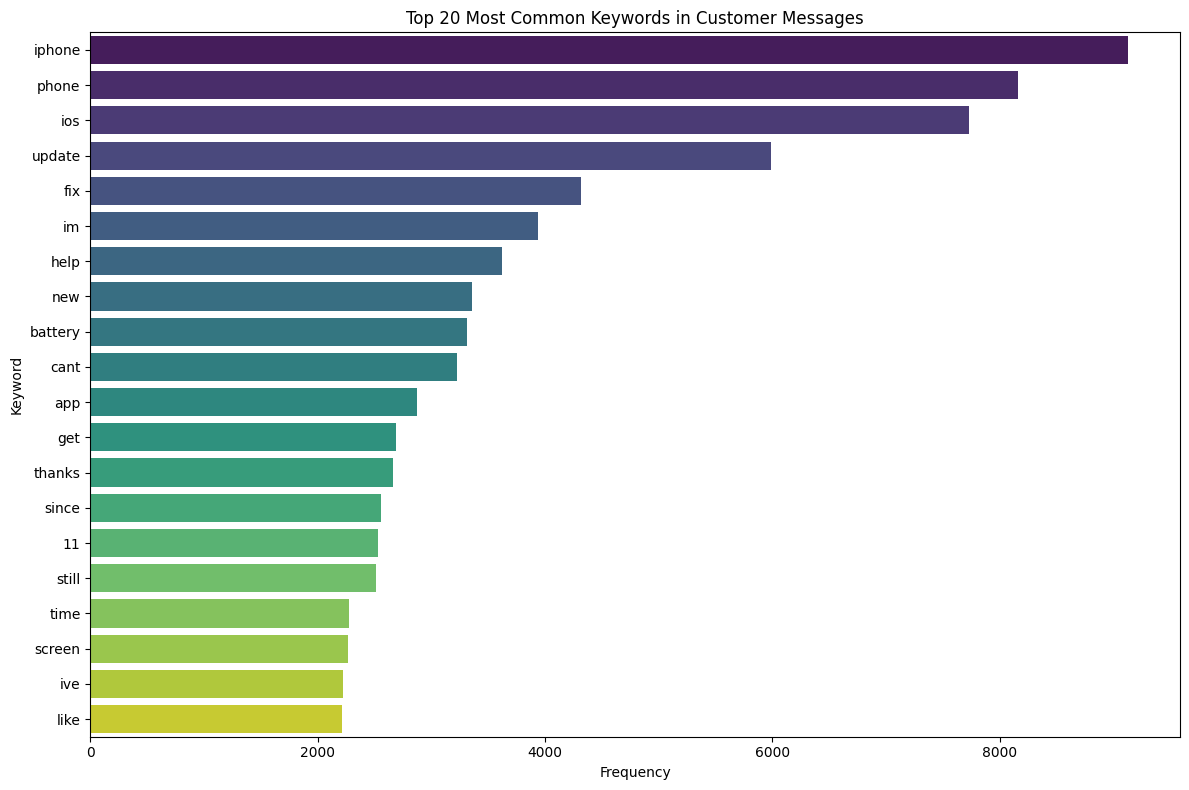

In [56]:
from itertools import chain

# Flatten the list of tokens and count word frequencies
all_customer_tokens = list(chain.from_iterable(customer_inbound_messages['cleaned_tokens']))
word_freq = Counter(all_customer_tokens)

# Get the 20 most common words
common_words = word_freq.most_common(20)

print("Top 20 Most Common Keywords in Customer Messages:")
for word, freq in common_words:
    print(f"- {word}: {freq:,}")

# Visualize common words
words_df = pd.DataFrame(common_words, columns=['Word', 'Frequency'])
plt.figure(figsize=(12, 8))
sns.barplot(x='Frequency', y='Word', data=words_df, palette='viridis')
plt.title('Top 20 Most Common Keywords in Customer Messages')
plt.xlabel('Frequency')
plt.ylabel('Keyword')
plt.tight_layout()
plt.show()

### Useful Bigrams (Two-Word Phrases)

Top 20 Most Common Bigrams in Customer Messages:
- ios 11: 2,332
- ios 1103: 872
- iphone 6s: 860
- iphone plus: 694
- every time: 675
- battery life: 648
- ios 111: 618
- new update: 578
- ios 1102: 572
- doesnt work: 536
- new ios: 518
- question mark: 498
- ios update: 478
- ever since: 418
- new iphone: 408
- updated ios: 385
- high sierra: 385
- app store: 371
- ios 1112: 344
- lock screen: 327


/tmp/ipykernel_6571/1631510095.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Frequency', y='Bigram', data=bigrams_df, palette='magma')


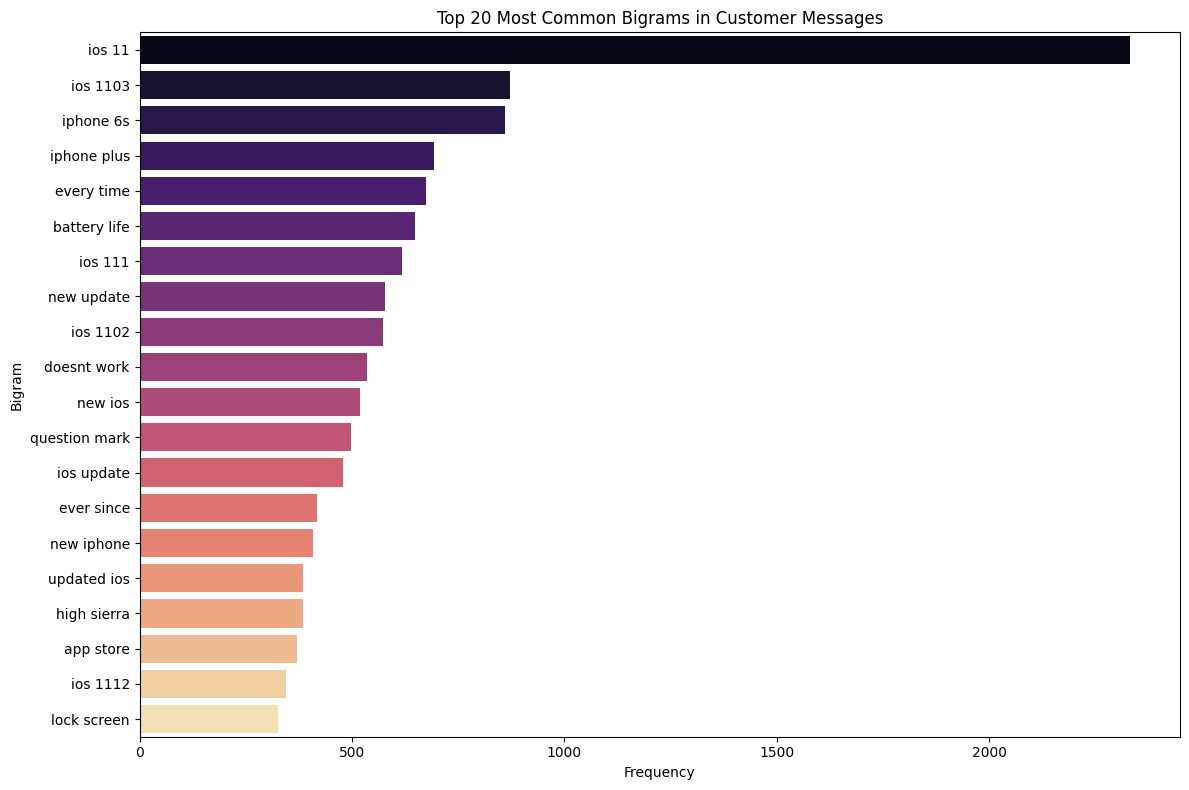

In [57]:
from nltk.util import ngrams

# Generate bigrams from the cleaned tokens
all_customer_bigrams = list(chain.from_iterable(ngrams(tokens, 2) for tokens in customer_inbound_messages['cleaned_tokens']))
bigram_freq = Counter(all_customer_bigrams)

# Get the 20 most common bigrams
common_bigrams = bigram_freq.most_common(20)

print("Top 20 Most Common Bigrams in Customer Messages:")
for bigram, freq in common_bigrams:
    print(f"- {' '.join(bigram)}: {freq:,}")

# Visualize common bigrams
bigrams_df = pd.DataFrame([(' '.join(bigram), freq) for bigram, freq in common_bigrams], columns=['Bigram', 'Frequency'])
plt.figure(figsize=(12, 8))
sns.barplot(x='Frequency', y='Bigram', data=bigrams_df, palette='magma')
plt.title('Top 20 Most Common Bigrams in Customer Messages')
plt.xlabel('Frequency')
plt.ylabel('Bigram')
plt.tight_layout()
plt.show()

### Common Issue-Related Terms and Potential Intents

Based on the common keywords and bigrams, we can infer several prevalent issues and potential support intents:

*   **Device-Specific Issues**: Words like 'iphone', 'ios', 'phone', 'mac', 'watch', 'ipad' indicate that many queries are about specific Apple devices or operating systems.
*   **Performance/Functionality Problems**: Terms such as 'update', 'problem', 'fix', 'bug', 'working', 'battery', 'screen', 'storage', 'data', 'download' suggest customers frequently face issues with their devices' performance, software bugs, battery life, screen functionality, or data management.
*   **Account/Service Issues**: Keywords like 'icloud', 'id', 'account', 'app store', 'music' point to problems with Apple services, account access, or app-related concerns.
*   **Connectivity Issues**: 'wifi', 'cellular', 'internet', 'network' would indicate connectivity problems.
*   **Software Updates**: The frequent appearance of 'update', 'ios update' highlights issues or questions related to software updates, including installation problems or post-update bugs.

These findings suggest that a robust AI support agent should be capable of:
*   **Categorizing issues**: e.g., 'Battery Drain', 'Software Update Issues', 'App Not Working', 'Connectivity Problem'.
*   **Identifying device types**: To provide device-specific troubleshooting.
*   **Extracting key entities**: Such as 'iOS version', 'app name', 'error message'.
*   **Providing immediate solutions/FAQs**: For common, easily resolvable problems.
*   **Escalating complex issues**: To human agents with relevant context.

# 7. Dataset Preparation for Model Training

For training an AI support agent, we need to prepare a dataset where each entry consists of a customer's message (query) and the corresponding support agent's response. This section focuses on creating such pairs from the conversation threads identified earlier. The primary goal is to ensure that each support response is paired with the customer message it is directly replying to, while also considering the flow of conversation.

### Extract Customer-Support Pairs

In [58]:
conversation_pairs = []

for thread_info in conversation_threads_data:
    thread_df = thread_info['thread_df']

    # Iterate through the tweets in the thread to find customer-support pairs
    for i in range(len(thread_df)):
        current_tweet = thread_df.iloc[i]

        # If the current tweet is a support response (inbound=False) and is a reply to another tweet
        if not current_tweet['inbound'] and pd.notna(current_tweet['in_response_to_tweet_id']):
            # Find the tweet it's in response to
            in_response_to_id = current_tweet['in_response_to_tweet_id']
            # Convert to int for matching, if the original ID is a float
            in_response_to_id = int(in_response_to_id) if pd.notna(in_response_to_id) else None

            if in_response_to_id:
                # Find the parent tweet within the same thread
                parent_tweet = thread_df[thread_df['tweet_id'] == in_response_to_id]

                if not parent_tweet.empty:
                    parent_tweet = parent_tweet.iloc[0]

                    # Ensure the parent tweet is from a customer (inbound=True)
                    if parent_tweet['inbound']:
                        conversation_pairs.append({
                            'customer_tweet_id': parent_tweet['tweet_id'],
                            'customer_text': parent_tweet['text'],
                            'support_tweet_id': current_tweet['tweet_id'],
                            'support_text': current_tweet['text']
                        })

print(f"Extracted {len(conversation_pairs):,} potential customer-support pairs.")

# Convert to DataFrame
pairs_df = pd.DataFrame(conversation_pairs)
print("First 5 extracted pairs:")
display(pairs_df.head())

Extracted 1,514 potential customer-support pairs.
First 5 extracted pairs:


,customer_tweet_id,customer_text,support_tweet_id,support_text
0,698,@AppleSupport https://t.co/NV0yucs0lB,696,@115854 We're here for you. Which version of t...
1,697,@AppleSupport The newest update. I️ made sure ...,699,@115854 Lets take a closer look into this issu...
2,714,Hey @AppleSupport and anyone else who upgraded...,712,"@115856 Hey, let's work together to figure out..."
3,723,@115858 @AppleSupport hello are all the lines ...,722,@115859 What's going on? We're hapy to help if...
4,721,@AppleSupport are the call centres closed for ...,720,@115859 We've received your DM and will contin...
